# DGEMM Cube Sweep — 3D Heatmap of Energy & Power vs. (M, N, K)

Loads the DGEMM sweep at `/Users/hom/Downloads/dgemm-cube2`, attributes energy (J) and average power (W) to each `rocblas_dgemm` call, then visualizes both as 3D heatmap cubes over the (M, N, K) parameter space.

In [149]:
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ampere import Ensemble, MetricConfig, MetricType, connect, set_backend, DataFrame
# import arkouda as ak

set_backend("pandas")
connect(server="localhost", port=5555)

Pandas backend active — skipping Arkouda connection.


In [150]:
# Metric configs — cumulative energy counter (µJ -> J) and PPT.
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

# Map device-local energy counters to the MPI ranks that use that GPU.
def my_hpc_topology(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

ENERGY_METRICS = [
    "A2rocm_smi:::energy_count:device=0",
    # "A2rocm_smi:::energy_count:device=2",
    # "A2rocm_smi:::energy_count:device=4",
    # "A2rocm_smi:::energy_count:device=6",
]

In [151]:
TRACE_PATH = "/Users/hom/Downloads/dgemm-cube6"
TRACE_PATH = "/Users/hom/Downloads/dgemm-cube9"
ranks = [f"MPI Rank {i}" for i in range(8)]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths([TRACE_PATH], topo, configs)

Loading Runs: 100%|██████████| 1/1 [00:05<00:00,  5.23s/it]


## Attribute energy (J) and power (W) per call
Each `rocblas_dgemm` invocation in the trace carries `{m, n, k}` metadata. We attribute the cumulative energy counter to each call (Joules) and again as a rate (Watts).

In [152]:
df_joules = DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, strategy='exclusive')
    for m in ENERGY_METRICS
]).to_pandas()

df_watts = DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, output_mode='rate', strategy='exclusive')
    for m in ENERGY_METRICS
]).to_pandas()

print(f"Joules rows: {len(df_joules):,}   Watts rows: {len(df_watts):,}")

Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  3.26it/s]

Joules rows: 62,939   Watts rows: 62,939


In [153]:
def dgemm_with_mnk(df):
    """Keep only rocblas_dgemm rows and expand the m/n/k metadata into columns."""
    sub = df[df['Name'].str.contains('rocblas_dgemm', case=False, na=False)].copy()
    meta = sub['Metadata'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (x or {}))
    meta_df = meta.apply(pd.Series)
    sub = pd.concat([sub.reset_index(drop=True), meta_df.reset_index(drop=True)], axis=1)
    sub = sub.dropna(subset=['m', 'n', 'k'])
    sub[['m', 'n', 'k']] = sub[['m', 'n', 'k']].astype(int)
    sub['Duration'] = sub['End Time'] - sub['Start Time']
    return sub

dgemm_j = dgemm_with_mnk(df_joules).rename(columns={'Value': 'Energy_J'})
dgemm_w = dgemm_with_mnk(df_watts).rename(columns={'Value': 'Power_W'})

print(f"DGEMM calls (energy): {len(dgemm_j):,}")
print(f"DGEMM calls (power):  {len(dgemm_w):,}")
print("\nUnique M values:", sorted(dgemm_j['m'].unique())[:10], '...')
print("Unique N values:", sorted(dgemm_j['n'].unique())[:10], '...')
print("Unique K values:", sorted(dgemm_j['k'].unique())[:10], '...')

DGEMM calls (energy): 62,927
DGEMM calls (power):  62,927

Unique M values: [np.int64(1024), np.int64(2048), np.int64(3072), np.int64(4096), np.int64(5120), np.int64(6144), np.int64(7168), np.int64(8192), np.int64(9216), np.int64(10240)] ...
Unique N values: [np.int64(1024), np.int64(2048), np.int64(3072), np.int64(4096), np.int64(5120), np.int64(6144), np.int64(7168), np.int64(8192), np.int64(9216), np.int64(10240)] ...
Unique K values: [np.int64(1024), np.int64(2048), np.int64(3072), np.int64(4096), np.int64(5120), np.int64(6144), np.int64(7168), np.int64(8192), np.int64(9216), np.int64(10240)] ...


In [154]:
# Average energy / power per (m, n, k) cell of the cube.
energy_cube = dgemm_j.groupby(['m', 'n', 'k'], as_index=False).agg(
    Energy_J=('Energy_J', 'mean'),
    Duration=('Duration', 'mean'),
    Calls=('Energy_J', 'count'),
)
power_cube = dgemm_w.groupby(['m', 'n', 'k'], as_index=False).agg(
    Power_W=('Power_W', 'mean'),
    Duration=('Duration', 'mean'),
    Calls=('Power_W', 'count'),
)
cube = energy_cube.merge(power_cube[['m', 'n', 'k', 'Power_W']], on=['m', 'n', 'k'])
print(f"Unique (M, N, K) cells: {len(cube):,}")
display(cube.head(100000))

Unique (M, N, K) cells: 13,824


,m,n,k,Energy_J,Duration,Calls,Power_W
0,1024,1024,1024,0.031769,0.000194,130,109.503882
1,1024,1024,2048,0.034297,0.000173,87,198.726006
2,1024,1024,3072,0.076025,0.000360,37,210.472832
3,1024,1024,4096,0.079462,0.000404,36,196.368284
4,1024,1024,5120,0.090258,0.000485,34,184.281136
...,...,...,...,...,...,...,...
13819,24576,24576,20480,174.060796,0.681338,4,255.469449
13820,24576,24576,21504,183.029465,0.714824,4,256.048466
13821,24576,24576,22528,192.246404,0.749331,4,256.557733
13822,24576,24576,23552,199.726323,0.782025,4,255.395001


## 3D cube heatmap (matplotlib)
Each point is one (M, N, K) cell of the sweep; colour encodes energy or average power.

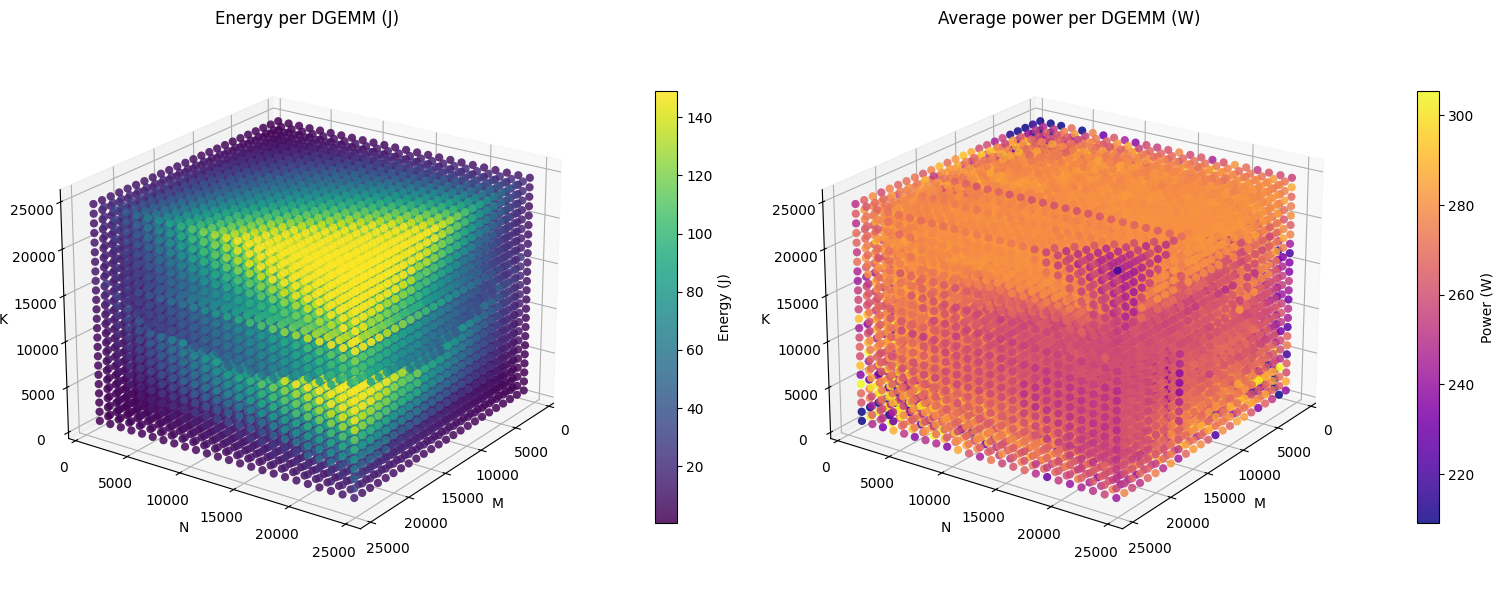

In [ ]:
def cube_scatter(ax, df, value_col, title, cmap):
    vmin, vmax = df[value_col].quantile(0.02), df[value_col].quantile(0.98)
    sc = ax.scatter(
        df['m'], df['n'], df['k'],
        c=df[value_col], cmap=cmap, s=35, alpha=0.85,
        edgecolors='none', vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
    ax.set_title(title)
    ax.view_init(elev=22, azim=35)
    return sc

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = cube_scatter(ax1, cube, 'Energy_J', 'Energy per DGEMM (J)', 'viridis')
fig.colorbar(sc1, ax=ax1, pad=0.1, shrink=0.7, label='Energy (J)')
# Add margin on the left so the K isnt cut off
fig.tight_layout(pad=3.0)
fig.savefig("dgemm_energy_cube.png", facecolor='white', dpi=600, bbox_inches='tight', pad_inches=0.3)


ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = cube_scatter(ax2, cube, 'Power_W', 'Average power per DGEMM (W)', 'plasma')
fig.colorbar(sc2, ax=ax2, pad=0.1, shrink=0.7, label='Power (W)')
fig.savefig("dgemm_power_cube.png", facecolor='white', dpi=600, bbox_inches='tight', pad_inches=0.3)
fig.tight_layout(pad=3.0)

plt.savefig("dgemm_energy_power_cube.png", facecolor='white', bbox_inches='tight', dpi=600)
plt.show()

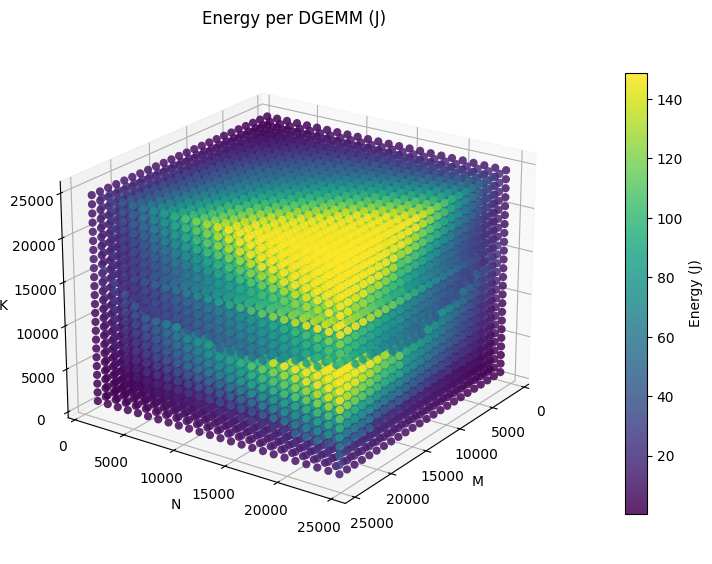

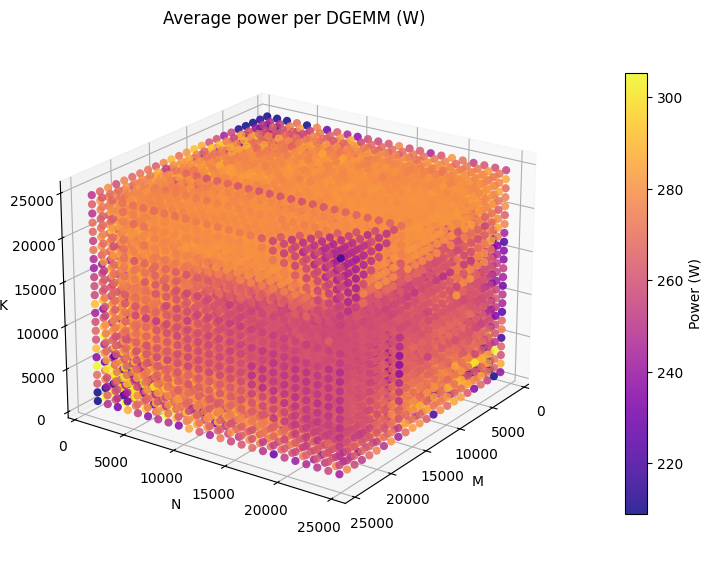

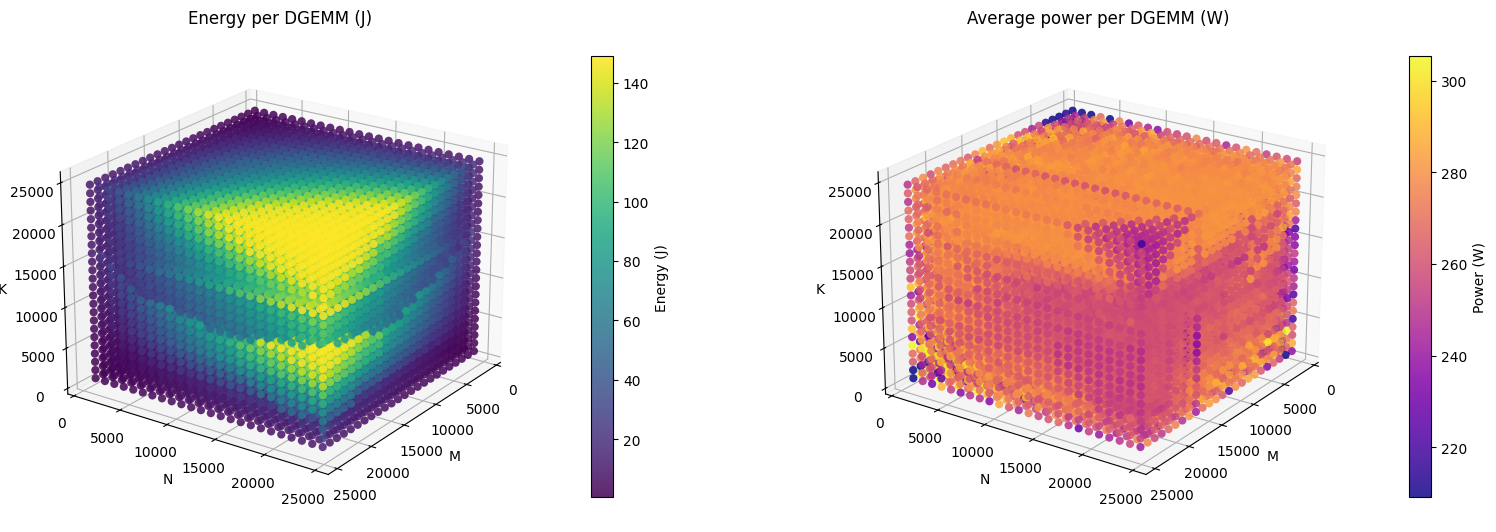

In [196]:
def cube_scatter(ax, df, value_col, title, cmap):
    vmin, vmax = df[value_col].quantile(0.02), df[value_col].quantile(0.98)
    sc = ax.scatter(
        df['m'], df['n'], df['k'],
        c=df[value_col], cmap=cmap, s=35, alpha=0.85,
        edgecolors='none', vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
    ax.set_title(title)
    ax.view_init(elev=22, azim=35)
    return sc

# --- Individual figure: Energy ---
fig_e = plt.figure(figsize=(8, 7))
ax_e = fig_e.add_subplot(1, 1, 1, projection='3d')
sc_e = cube_scatter(ax_e, cube, 'Energy_J', 'Energy per DGEMM (J)', 'viridis')
fig_e.colorbar(sc_e, ax=ax_e, pad=0.1, shrink=0.7, label='Energy (J)')
fig_e.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.05)
fig_e.savefig("dgemm_energy_cube.png", facecolor='white', dpi=600)

# --- Individual figure: Power ---
fig_p = plt.figure(figsize=(8, 7))
ax_p = fig_p.add_subplot(1, 1, 1, projection='3d')
sc_p = cube_scatter(ax_p, cube, 'Power_W', 'Average power per DGEMM (W)', 'plasma')
fig_p.colorbar(sc_p, ax=ax_p, pad=0.1, shrink=0.7, label='Power (W)')
fig_p.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.05)
fig_p.savefig("dgemm_power_cube.png", facecolor='white', dpi=600)

# --- Combined figure: both cubes ---
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = cube_scatter(ax1, cube, 'Energy_J', 'Energy per DGEMM (J)', 'viridis')
fig.colorbar(sc1, ax=ax1, pad=0.1, shrink=0.7, label='Energy (J)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = cube_scatter(ax2, cube, 'Power_W', 'Average power per DGEMM (W)', 'plasma')
fig.colorbar(sc2, ax=ax2, pad=0.1, shrink=0.7, label='Power (W)')

fig.subplots_adjust(left=0.04, right=0.96, top=0.95, bottom=0.05, wspace=0.25)
fig.savefig("dgemm_energy_power_cube.png", facecolor='white', dpi=600)
plt.show()

## Interactive 3D cube (Plotly)
Drag to rotate. Hover for the (M, N, K) cell value.

In [156]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('Energy per DGEMM (J)', 'Average power per DGEMM (W)'),
)

fig.add_trace(go.Scatter3d(
    x=cube['m'], y=cube['n'], z=cube['k'], mode='markers',
    marker=dict(size=7, color=cube['Energy_J'], colorscale='Viridis',
                colorbar=dict(title='Energy (J)', x=0.45), opacity=0.6),
    customdata=np.stack([cube['Energy_J'], cube['Calls']], axis=-1),
    hovertemplate='M=%{x}, N=%{y}, K=%{z}<br>Energy=%{customdata[0]:.2f} J<br>Calls=%{customdata[1]}<extra></extra>',
    name='Energy',
), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=cube['m'], y=cube['n'], z=cube['k'], mode='markers',
    marker=dict(size=7, color=cube['Power_W'], colorscale='Plasma',
                colorbar=dict(title='Power (W)', x=1.0), opacity=0.6),
    customdata=np.stack([cube['Power_W'], cube['Calls']], axis=-1),
    hovertemplate='M=%{x}, N=%{y}, K=%{z}<br>Power=%{customdata[0]:.2f} W<br>Calls=%{customdata[1]}<extra></extra>',
    name='Power',
), row=1, col=2)

scene = dict(xaxis_title='M', yaxis_title='N', zaxis_title='K')
fig.update_layout(height=650, width=1300, scene=scene, scene2=scene,
                  title='DGEMM cube sweep — (M, N, K) vs. energy & power')
fig.show()

## 2D slices through the cube
One (M × N) heatmap per distinct K value — useful when 3D occlusion hides interior trends.

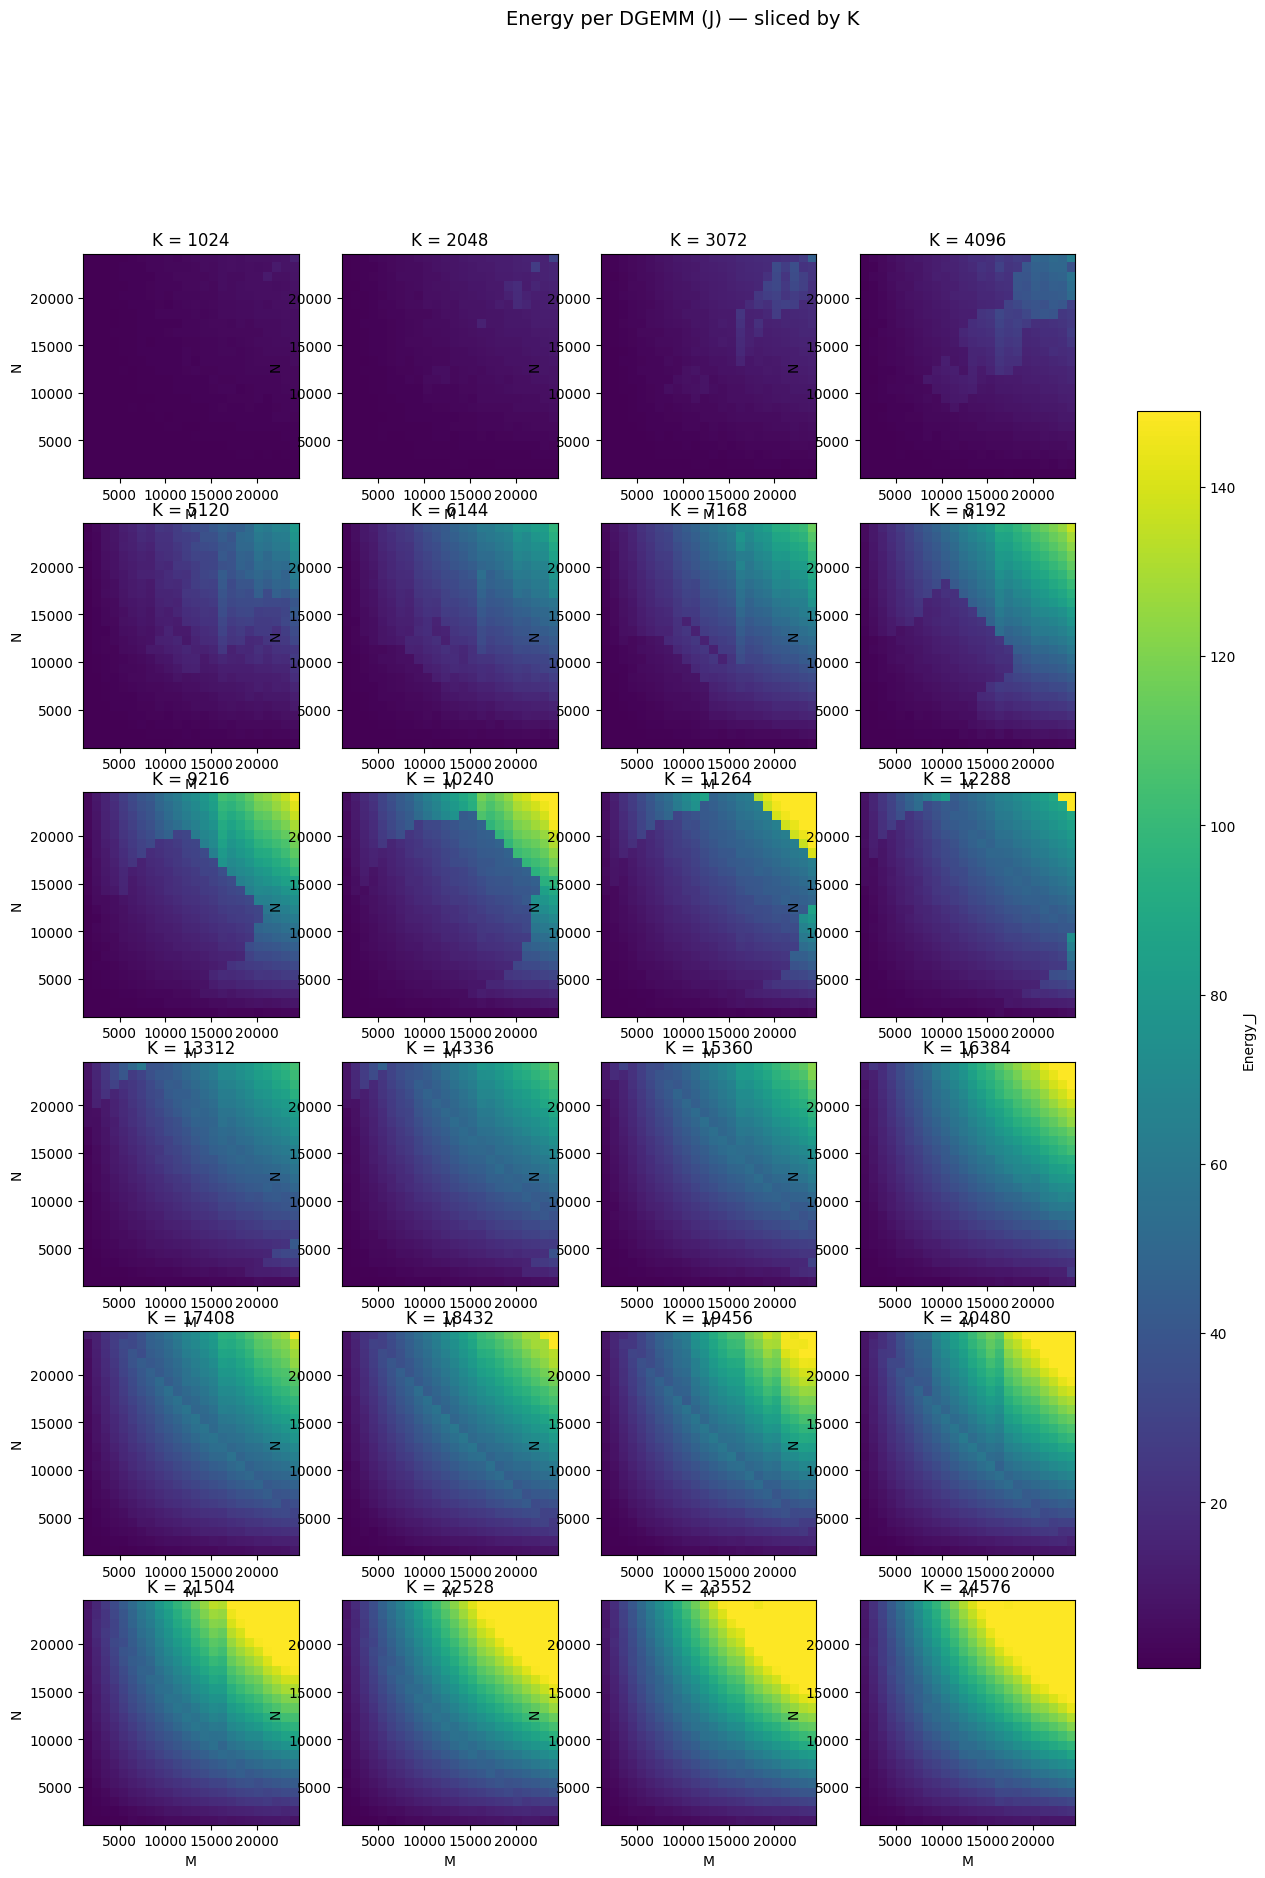

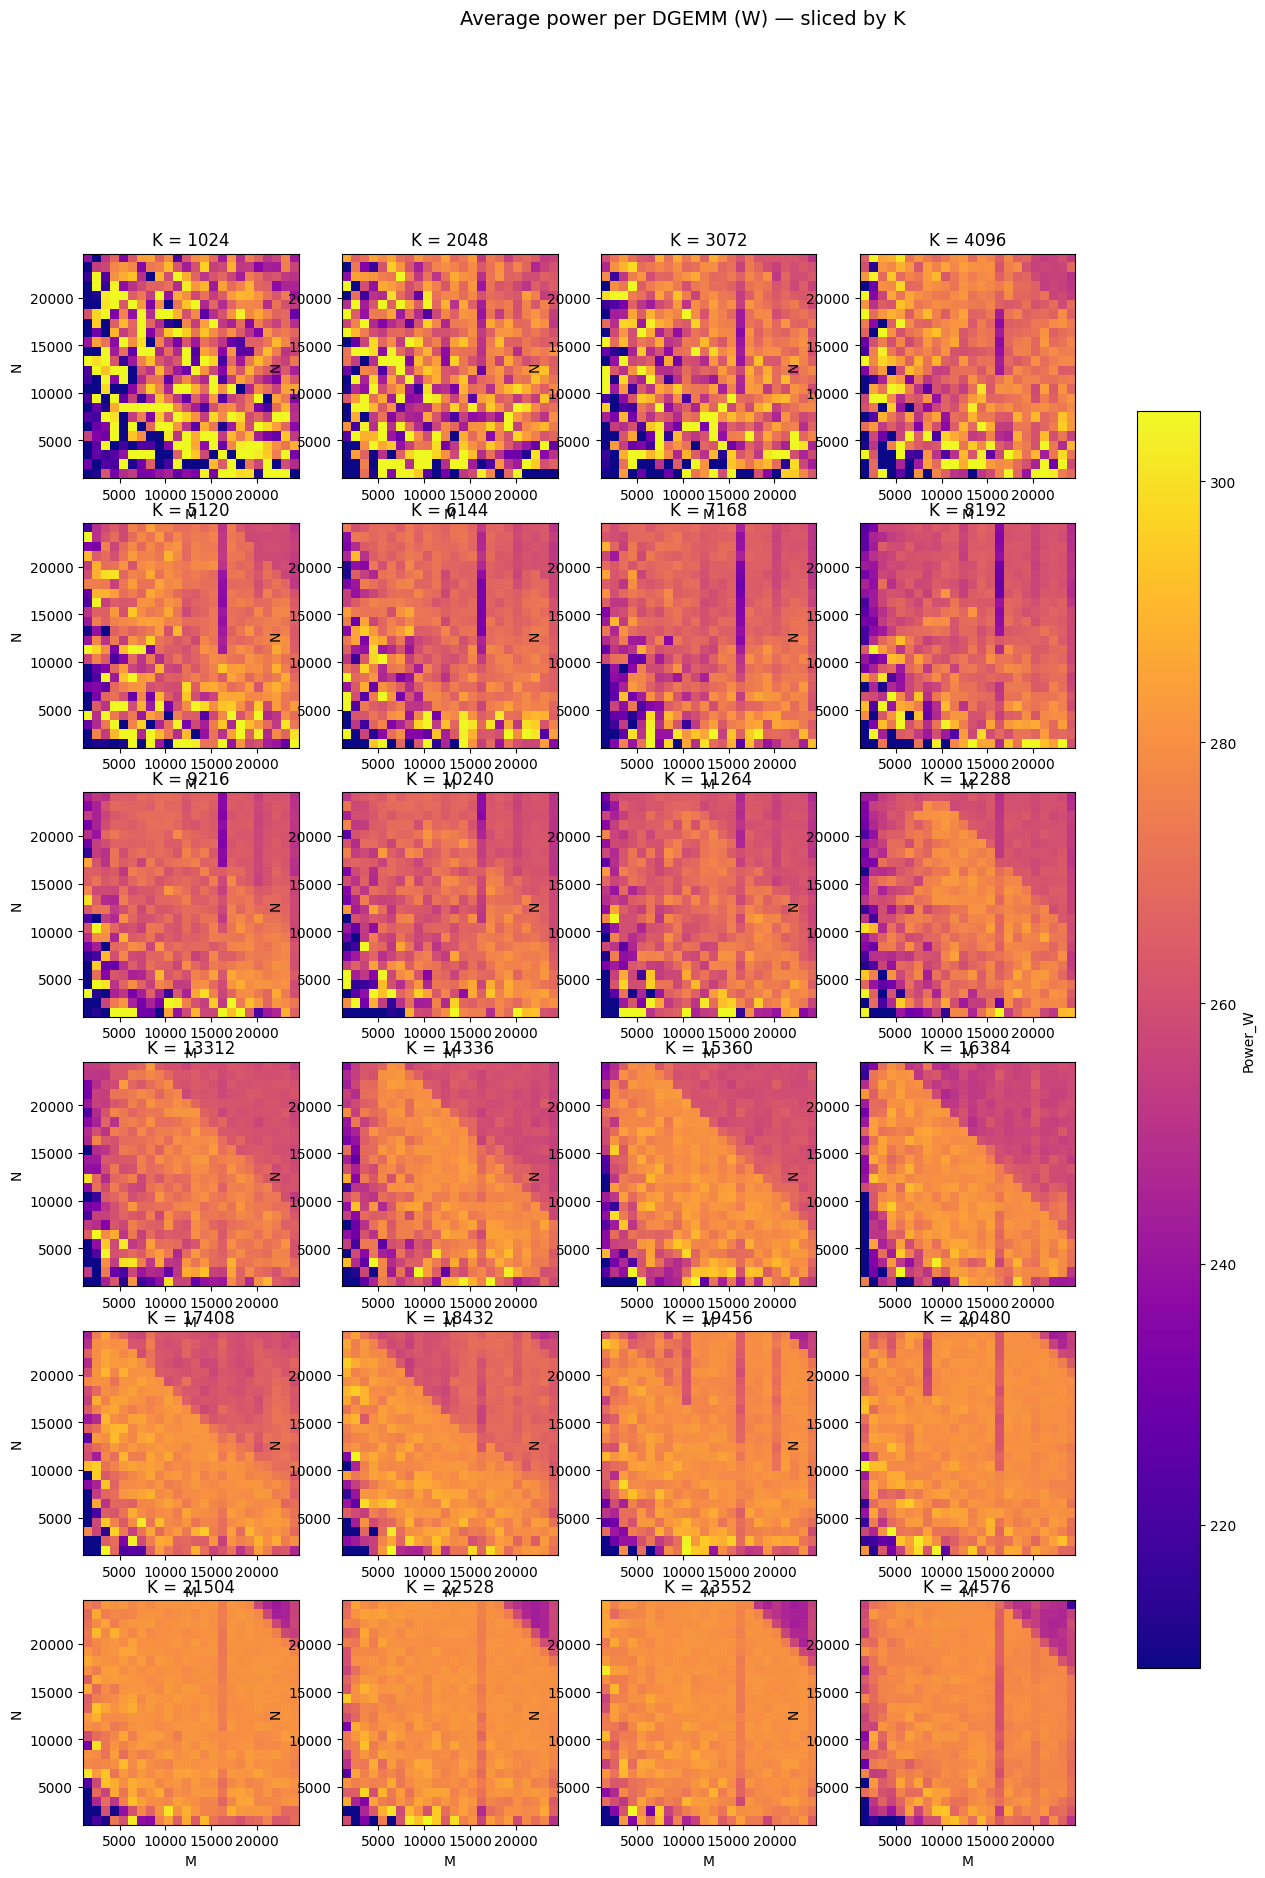

In [157]:
def slice_panels(df, value_col, title, cmap):
    k_values = sorted(df['k'].unique())
    n_k = len(k_values)
    cols = min(4, n_k)
    rows = int(np.ceil(n_k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows), squeeze=False)
    vmin, vmax = df[value_col].quantile(0.02), df[value_col].quantile(0.98)
    for ax, k in zip(axes.flat, k_values):
        pivot = (df[df['k'] == k]
                 .pivot_table(index='n', columns='m', values=value_col, aggfunc='mean')
                 .sort_index().sort_index(axis=1))
        im = ax.imshow(pivot.values, origin='lower', aspect='auto', cmap=cmap,
                       vmin=vmin, vmax=vmax,
                       extent=[pivot.columns.min(), pivot.columns.max(),
                               pivot.index.min(), pivot.index.max()])
        ax.set_title(f'K = {k}')
        ax.set_xlabel('M'); ax.set_ylabel('N')
    for ax in axes.flat[n_k:]:
        ax.axis('off')
    fig.suptitle(title, y=1.0, fontsize=14)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label=value_col)
    plt.show()

slice_panels(cube, 'Energy_J', 'Energy per DGEMM (J) — sliced by K', 'viridis')
slice_panels(cube, 'Power_W',  'Average power per DGEMM (W) — sliced by K', 'plasma')

## Top energy / power cells

In [158]:
print('Top 10 (M, N, K) cells by mean energy per call:')
display(cube.nlargest(10, 'Energy_J')[['m', 'n', 'k', 'Energy_J', 'Power_W', 'Duration', 'Calls']])

print('Top 10 (M, N, K) cells by mean power per call:')
display(cube.nlargest(10, 'Power_W')[['m', 'n', 'k', 'Energy_J', 'Power_W', 'Duration', 'Calls']])

Top 10 (M, N, K) cells by mean energy per call:


,m,n,k,Energy_J,Power_W,Duration,Calls
13811,24576,24576,12288,209.157364,247.171489,0.846201,4
13787,24576,23552,12288,200.315522,249.581582,0.802580,4
13799,24576,23552,24576,199.858031,254.897099,0.784072,4
13822,24576,24576,23552,199.726323,255.395001,0.782025,4
13775,24576,22528,24576,193.901280,259.287460,0.747828,4
13235,23552,24576,12288,192.552806,258.610659,0.744562,4
13798,24576,23552,23552,192.473404,256.122801,0.751486,4
13821,24576,24576,22528,192.246404,256.557733,0.749331,4
13247,23552,24576,24576,191.467171,247.765339,0.772786,4
13797,24576,23552,22528,185.251340,257.249930,0.720122,4


Top 10 (M, N, K) cells by mean power per call:


,m,n,k,Energy_J,Power_W,Duration,Calls
840,2048,12288,1024,0.584098,414.044203,0.001408,14
12096,22528,1024,1024,0.516819,400.361041,0.001291,16
1778,4096,3072,3072,0.822063,397.933594,0.002065,10
2905,6144,2048,2048,0.519239,392.815823,0.001319,16
6914,13312,1024,3072,0.855712,392.121209,0.002177,10
3048,6144,8192,1024,1.070837,391.578459,0.002731,8
218,1024,10240,3072,0.656353,389.532986,0.001681,12
11520,21504,1024,1024,0.500583,389.453680,0.001283,16
2401,5120,5120,2048,1.074159,385.304033,0.002786,8
2928,6144,3072,1024,0.416661,384.682359,0.001078,18


## Quantifying the (M, N, K) → energy & power relationship

DGEMM does `2·M·N·K` floating-point operations and touches `8·(M·K + K·N + M·N)` bytes (double precision, ignoring re-use). Their ratio — **arithmetic intensity** — is the standard predictor for whether a kernel is compute-bound or memory-bound. We therefore expect:

- **Energy** roughly linear in FLOPs = `2·M·N·K`, with a small per-call overhead.
- **Power** rising with arithmetic intensity and saturating at the device's TDP.

We test that with: (1) Pearson correlations, (2) a power-law fit `Energy ≈ A · FLOPs^α`, (3) a multivariate linear regression comparing different feature sets, and (4) a 4-panel diagnostic.

In [159]:
# Derived features motivated by DGEMM theory:
#   FLOPs = 2·M·N·K
#   Bytes ≈ 8·(M·K + K·N + M·N)        (DP, no re-use)
#   Arithmetic intensity = FLOPs / Bytes
cube['FLOPs']    = 2.0 * cube['m'] * cube['n'] * cube['k']
cube['Bytes']    = 8.0 * (cube['m']*cube['k'] + cube['k']*cube['n'] + cube['m']*cube['n'])
cube['AI']       = cube['FLOPs'] / cube['Bytes']
cube['logE']     = np.log(cube['Energy_J'])
cube['logFLOPs'] = np.log(cube['FLOPs'])

features = ['m', 'n', 'k', 'FLOPs', 'Bytes', 'AI', 'Duration']
corr = cube[features + ['Energy_J', 'Power_W']].corr()[['Energy_J', 'Power_W']].loc[features]
print('Pearson correlation with Energy and Power:')
display(corr.round(3))

Pearson correlation with Energy and Power:


,Energy_J,Power_W
m,0.513,0.132
n,0.511,0.005
k,0.472,0.174
FLOPs,0.964,0.072
Bytes,0.945,0.128
AI,0.901,0.148
Duration,0.998,0.054


In [160]:
# Power-law fit on the log-log plane:  Energy = A · FLOPs^α
slope, intercept = np.polyfit(cube['logFLOPs'], cube['logE'], 1)
prefactor = np.exp(intercept)
pred_log = slope * cube['logFLOPs'] + intercept
ss_res = ((cube['logE'] - pred_log) ** 2).sum()
ss_tot = ((cube['logE'] - cube['logE'].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print(f'Power-law fit:   Energy ≈ {prefactor:.3e} · FLOPs^{slope:.4f}')
print(f'                 R² (log-log) = {r2:.4f}')
print(f'Slope α ≈ 1 means energy is essentially linear in FLOPs.')

# Linear fit Energy = a + b·FLOPs  (no log) — gives pJ/FLOP and per-call overhead
b, a = np.polyfit(cube['FLOPs'], cube['Energy_J'], 1)
print(f'\nLinear fit:      Energy ≈ {a:.4f} J  +  {b*1e12:.3f} pJ/FLOP · FLOPs')
print(f'  • intercept   {a*1000:.2f} mJ      → fixed per-call overhead')
print(f'  • slope        {b*1e12:.3f} pJ/FLOP → asymptotic energy efficiency')
print(f'                ⇒ peak efficiency ≈ {1/(b*1e12):.2f} GFLOP/J')

Power-law fit:   Energy ≈ 3.560e-12 · FLOPs^1.0286
                 R² (log-log) = 0.9791
Slope α ≈ 1 means energy is essentially linear in FLOPs.

Linear fit:      Energy ≈ 2.2072 J  +  7.670 pJ/FLOP · FLOPs
  • intercept   2207.22 mJ      → fixed per-call overhead
  • slope        7.670 pJ/FLOP → asymptotic energy efficiency
                ⇒ peak efficiency ≈ 0.13 GFLOP/J


In [161]:
from sklearn.linear_model import LinearRegression

cube['mn'] = cube['m'] * cube['n']
cube['mk'] = cube['m'] * cube['k']
cube['nk'] = cube['n'] * cube['k']

trials = {
    'M only':                     ['m'],
    'M + N + K (linear)':         ['m', 'n', 'k'],
    'M·N + M·K + N·K (pairs)':    ['mn', 'mk', 'nk'],
    'M·N·K  (= ½·FLOPs)':         ['FLOPs'],
    'FLOPs + Bytes':              ['FLOPs', 'Bytes'],
    'FLOPs + Bytes + AI':         ['FLOPs', 'Bytes', 'AI'],
    'FLOPs + Bytes + M+N+K':      ['FLOPs', 'Bytes', 'm', 'n', 'k'],
}

print(f"{'Feature set':<32} {'R² Energy':>12} {'R² Power':>12}")
print('-' * 58)
for name, feats in trials.items():
    Xf = cube[feats]
    r2_e = LinearRegression().fit(Xf, cube['Energy_J']).score(Xf, cube['Energy_J'])
    r2_p = LinearRegression().fit(Xf, cube['Power_W']).score(Xf, cube['Power_W'])
    print(f"{name:<32} {r2_e:>12.4f} {r2_p:>12.4f}")

# Coefficients of the best linear model for energy
best_feats = ['FLOPs', 'Bytes', 'm', 'n', 'k']
mdl = LinearRegression().fit(cube[best_feats], cube['Energy_J'])
print('\nLinear model — Energy_J  =  intercept + Σ cᵢ · featureᵢ')
print(f'  intercept = {mdl.intercept_:.4f}')
for f, c in zip(best_feats, mdl.coef_):
    print(f'  {f:<8} coef = {c: .4e}')

Feature set                         R² Energy     R² Power
----------------------------------------------------------
M only                                 0.2627       0.0174
M + N + K (linear)                     0.7472       0.0478
M·N + M·K + N·K (pairs)                0.8945       0.0446
M·N·K  (= ½·FLOPs)                     0.9295       0.0052
FLOPs + Bytes                          0.9338       0.0496
FLOPs + Bytes + AI                     0.9341       0.0719
FLOPs + Bytes + M+N+K                  0.9350       0.0770

Linear model — Energy_J  =  intercept + Σ cᵢ · featureᵢ
  intercept = -0.6406
  FLOPs    coef =  5.4606e-12
  Bytes    coef =  4.8822e-09
  m        coef = -1.1214e-04
  n        coef = -1.1836e-04
  k        coef = -3.2280e-04


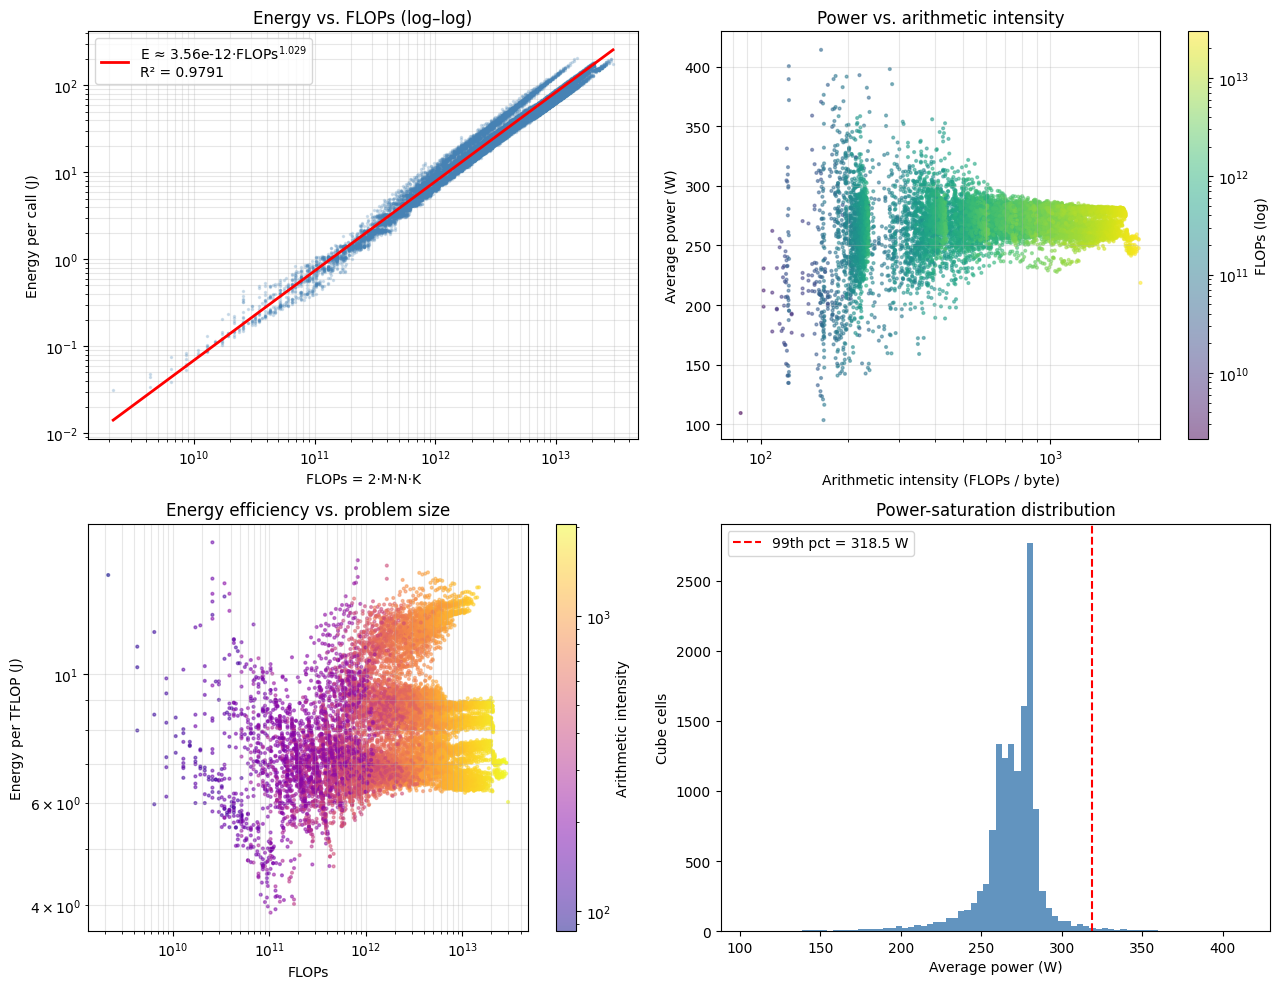

In [162]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Energy vs FLOPs — log-log with power-law fit overlay
ax = axes[0, 0]
ax.loglog(cube['FLOPs'], cube['Energy_J'], '.', alpha=0.2, ms=3, color='steelblue')
xs = np.array([cube['FLOPs'].min(), cube['FLOPs'].max()])
ax.loglog(xs, prefactor * xs**slope, 'r-', lw=2,
          label=f'E ≈ {prefactor:.2e}·FLOPs$^{{{slope:.3f}}}$\nR² = {r2:.4f}')
ax.set_xlabel('FLOPs = 2·M·N·K')
ax.set_ylabel('Energy per call (J)')
ax.set_title('Energy vs. FLOPs (log–log)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

# (b) Power vs arithmetic intensity (roofline-style)
ax = axes[0, 1]
sc = ax.scatter(cube['AI'], cube['Power_W'], c=cube['FLOPs'], cmap='viridis',
                s=4, alpha=0.5, norm=mcolors.LogNorm())
ax.set_xscale('log')
ax.set_xlabel('Arithmetic intensity (FLOPs / byte)')
ax.set_ylabel('Average power (W)')
ax.set_title('Power vs. arithmetic intensity')
plt.colorbar(sc, ax=ax, label='FLOPs (log)')
ax.grid(True, which='both', alpha=0.3)

# (c) Energy efficiency vs problem size
ax = axes[1, 0]
cube['J_per_TFLOP'] = cube['Energy_J'] / (cube['FLOPs'] / 1e12)
sc = ax.scatter(cube['FLOPs'], cube['J_per_TFLOP'], c=cube['AI'],
                cmap='plasma', s=4, alpha=0.5, norm=mcolors.LogNorm())
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('FLOPs')
ax.set_ylabel('Energy per TFLOP (J)')
ax.set_title('Energy efficiency vs. problem size')
plt.colorbar(sc, ax=ax, label='Arithmetic intensity')
ax.grid(True, which='both', alpha=0.3)

# (d) Power saturation distribution
ax = axes[1, 1]
ax.hist(cube['Power_W'], bins=80, color='steelblue', alpha=0.85)
ax.axvline(cube['Power_W'].quantile(0.99), color='red', ls='--',
           label=f'99th pct = {cube["Power_W"].quantile(0.99):.1f} W')
ax.set_xlabel('Average power (W)'); ax.set_ylabel('Cube cells')
ax.set_title('Power-saturation distribution')
ax.legend()

plt.tight_layout(); plt.show()

In [163]:
n_total = len(cube)
tdp = cube['Power_W'].quantile(0.99)
saturated = (cube['Power_W'] > 0.95 * tdp).sum()

print('=' * 60)
print('  Summary: how (M, N, K) shapes energy and power')
print('=' * 60)
print(f'Cube cells analysed:               {n_total:,}')
print(f'Power-law exponent (E ∝ FLOPs^α):  α = {slope:.4f}   (1.0 = perfectly linear)')
print(f'Log-log R²:                        {r2:.4f}')
print(f'Asymptotic energy cost:            {b*1e12:.2f} pJ/FLOP  ({1/(b*1e12):.2f} GFLOP/J)')
print(f'Per-call fixed overhead:           {a*1000:.2f} mJ')
print(f'Saturated power (99th pct):        {tdp:.1f} W')
print(f'Cells within 5% of saturation:     {saturated:,} / {n_total:,} ({100*saturated/n_total:.1f}%)')
print()
print('Interpretation:')
print(f'  • Energy is essentially set by FLOPs = 2·M·N·K (α ≈ {slope:.2f}).')
print(f'  • Average power is governed by arithmetic intensity: small/skinny shapes')
print(f'    are memory-bound and run cooler; large square shapes saturate the GPU.')
print(f'  • The cheapest way to do a fixed amount of work is to run it at high AI')
print(f'    (large M, N, K together) so the per-call overhead and idle power amortise.')

  Summary: how (M, N, K) shapes energy and power
Cube cells analysed:               13,824
Power-law exponent (E ∝ FLOPs^α):  α = 1.0286   (1.0 = perfectly linear)
Log-log R²:                        0.9791
Asymptotic energy cost:            7.67 pJ/FLOP  (0.13 GFLOP/J)
Per-call fixed overhead:           2207.22 mJ
Saturated power (99th pct):        318.5 W
Cells within 5% of saturation:     329 / 13,824 (2.4%)

Interpretation:
  • Energy is essentially set by FLOPs = 2·M·N·K (α ≈ 1.03).
  • Average power is governed by arithmetic intensity: small/skinny shapes
    are memory-bound and run cooler; large square shapes saturate the GPU.
  • The cheapest way to do a fixed amount of work is to run it at high AI
    (large M, N, K together) so the per-call overhead and idle power amortise.


## A closed-form E(M, N, K) — and how wrong it tends to be

Goal: a function `predict_energy(M, N, K)` that returns Joules, plus an honest estimate of the error.

We try a few physically-motivated linear models and a log-space power-law model, score every one with **5-fold cross-validation** (so the error is generalization error, not training error), then pick the best by mean absolute percentage error and report:

- absolute error (RMSE, MAE, in Joules),
- relative error (MAPE, in %),
- a 95% prediction band derived from the CV residuals.

In [164]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


def make_features(M, N, K, kind):
    """Build a feature matrix for one of the candidate models."""
    M, N, K = np.asarray(M, float), np.asarray(N, float), np.asarray(K, float)
    flops = 2.0 * M * N * K
    bytes_ = 8.0 * (M*K + K*N + M*N)
    if kind == 'compute':         return np.column_stack([flops])
    if kind == 'roofline':        return np.column_stack([flops, bytes_])
    if kind == 'roofline+linear': return np.column_stack([flops, bytes_, M, N, K])
    if kind == 'pairs+flops':     return np.column_stack([M*N, M*K, N*K, flops])
    if kind == 'log-power-law':   return np.column_stack([np.log(M), np.log(N), np.log(K)])
    raise ValueError(kind)


def cv_score(kind, y, M, N, K, n_splits=5, log_target=False):
    """Return CV predictions on the original (Joules) scale and headline metrics."""
    X = make_features(M, N, K, kind)
    target = np.log(y) if log_target else y
    kf = KFold(n_splits, shuffle=True, random_state=0)
    preds_target = np.zeros_like(target, dtype=float)
    for tr, te in kf.split(X):
        mdl = LinearRegression().fit(X[tr], target[tr])
        preds_target[te] = mdl.predict(X[te])
    preds = np.exp(preds_target) if log_target else preds_target
    mae  = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mape = np.mean(np.abs((y - preds) / np.maximum(np.abs(y), 1e-9))) * 100
    r2   = 1 - ((y - preds)**2).sum() / ((y - y.mean())**2).sum()
    return preds, dict(R2=r2, MAE=mae, RMSE=rmse, MAPE=mape)


y = cube['Energy_J'].values
M, N, K = cube['m'].values, cube['n'].values, cube['k'].values

candidates = [
    ('compute',          False),   # E = c0 + c1·FLOPs
    ('roofline',         False),   # E = c0 + c1·FLOPs + c2·Bytes
    ('roofline+linear',  False),   # + c3·M + c4·N + c5·K
    ('pairs+flops',      False),   # M·N, M·K, N·K, FLOPs
    ('log-power-law',    True),    # log E = c0 + a·logM + b·logN + c·logK
]

results = {}
print(f"{'Model':<22} {'R²':>8} {'MAE (J)':>10} {'RMSE (J)':>10} {'MAPE %':>10}")
print('-' * 64)
for name, log_target in candidates:
    preds, m = cv_score(name, y, M, N, K, log_target=log_target)
    results[name] = (preds, m, log_target)
    print(f"{name:<22} {m['R2']:>8.4f} {m['MAE']:>10.4f} {m['RMSE']:>10.4f} {m['MAPE']:>10.2f}")

best_name = min(results, key=lambda k: results[k][1]['MAPE'])
print(f'\nBest model by MAPE: {best_name}')

Model                        R²    MAE (J)   RMSE (J)     MAPE %
----------------------------------------------------------------
compute                  0.9295     6.0532     9.8323      63.15
roofline                 0.9338     5.8513     9.5265      58.09
roofline+linear          0.9349     5.9618     9.4448      48.83
pairs+flops              0.9359     5.9009     9.3699      60.34
log-power-law            0.9156     5.8933    10.7554      16.75

Best model by MAPE: log-power-law


In [165]:
# Refit the best model on the full cube and expose a closed-form predictor.
best_log = results[best_name][2]
X_full = make_features(M, N, K, best_name)
target_full = np.log(y) if best_log else y
final_model = LinearRegression().fit(X_full, target_full)

# Use the CV residuals (held-out predictions) to estimate prediction-interval width.
preds_cv = results[best_name][0]
residuals = y - preds_cv                           # absolute residuals (J)
log_residuals = np.log(preds_cv) - np.log(y)       # multiplicative residuals
abs_lo, abs_hi = np.percentile(residuals, [2.5, 97.5])
mult_lo, mult_hi = np.exp(np.percentile(-log_residuals, [2.5, 97.5]))

# ---- Print the equation -------------------------------------------------
coef = final_model.coef_
icpt = final_model.intercept_

print('Closed-form equation:\n')
if best_name == 'compute':
    print(f'  E(M, N, K)  =  {icpt:+.6e}'
          f'  +  {coef[0]:+.6e} · (2·M·N·K)        [J]')
elif best_name == 'roofline':
    print(f'  E(M, N, K)  =  {icpt:+.6e}'
          f'\n              +  {coef[0]:+.6e} · (2·M·N·K)'
          f'\n              +  {coef[1]:+.6e} · 8·(M·K + K·N + M·N)   [J]')
elif best_name == 'roofline+linear':
    print(f'  E(M, N, K)  =  {icpt:+.6e}'
          f'\n              +  {coef[0]:+.6e} · (2·M·N·K)'
          f'\n              +  {coef[1]:+.6e} · 8·(M·K + K·N + M·N)'
          f'\n              +  {coef[2]:+.6e} · M  +  {coef[3]:+.6e} · N  +  {coef[4]:+.6e} · K   [J]')
elif best_name == 'pairs+flops':
    print(f'  E(M, N, K)  =  {icpt:+.6e}'
          f'\n              +  {coef[0]:+.6e} · M·N'
          f'\n              +  {coef[1]:+.6e} · M·K'
          f'\n              +  {coef[2]:+.6e} · N·K'
          f'\n              +  {coef[3]:+.6e} · (2·M·N·K)   [J]')
elif best_name == 'log-power-law':
    print(f'  E(M, N, K)  =  exp({icpt:+.4f}) · M^{coef[0]:.4f} · N^{coef[1]:.4f} · K^{coef[2]:.4f}   [J]')

# ---- Cross-validated error report ---------------------------------------
m = results[best_name][1]
print(f'\nGeneralization error  (5-fold CV, n = {len(y):,} cells):')
print(f'   MAE  = {m["MAE"]:.4f} J')
print(f'   RMSE = {m["RMSE"]:.4f} J')
print(f'   MAPE = {m["MAPE"]:.2f} %                ← typical relative error')
print(f'   R²   = {m["R2"]:.4f}')
print(f'\n95% prediction band (from CV residuals):')
print(f'   absolute:        estimate {abs_lo:+.3f} J  …  estimate {abs_hi:+.3f} J')
print(f'   multiplicative:  estimate × {mult_lo:.3f}  …  estimate × {mult_hi:.3f}')


# ---- Predictor function -------------------------------------------------
def predict_energy(M, N, K, return_interval=True):
    """Plug in M, N, K and get predicted DGEMM energy in Joules.

    Returns (estimate, lo95, hi95) when return_interval=True.
    Bounds are taken from cross-validated residuals on the training cube,
    so they reflect honest generalization error within the swept range.
    """
    M = np.atleast_1d(M); N = np.atleast_1d(N); K = np.atleast_1d(K)
    Xq = make_features(M, N, K, best_name)
    yhat_t = final_model.predict(Xq)
    yhat = np.exp(yhat_t) if best_log else yhat_t
    if not return_interval:
        return yhat
    if best_log:
        return yhat, yhat * mult_lo, yhat * mult_hi
    return yhat, yhat + abs_lo, yhat + abs_hi


# ---- Examples -----------------------------------------------------------
print('\nExample predictions:')
print(f"  {'M':>6} {'N':>6} {'K':>6}   {'E_pred (J)':>12}   {'95% CI (J)':>26}   {'measured (J)':>12}")
examples = [(512, 512, 512), (4096, 4096, 4096), (8192, 8192, 8192),
            (16384, 16384, 16384), (1024, 16384, 16384), (16384, 1024, 1024)]
lookup = cube.set_index(['m', 'n', 'k'])['Energy_J']
for Mi, Ni, Ki in examples:
    yhat, lo, hi = predict_energy(Mi, Ni, Ki)
    actual = lookup.get((Mi, Ni, Ki), np.nan)
    actual_s = f'{actual:12.4f}' if np.isfinite(actual) else f'{"—":>12}'
    print(f'  {Mi:6d} {Ni:6d} {Ki:6d}   {yhat[0]:12.4f}   [{lo[0]:10.4f}, {hi[0]:10.4f}]   {actual_s}')

Closed-form equation:

  E(M, N, K)  =  exp(-25.6484) · M^1.0259 · N^1.0284 · K^1.0315   [J]

Generalization error  (5-fold CV, n = 13,824 cells):
   MAE  = 5.8933 J
   RMSE = 10.7554 J
   MAPE = 16.75 %                ← typical relative error
   R²   = 0.9156

95% prediction band (from CV residuals):
   absolute:        estimate -25.367 J  …  estimate +25.007 J
   multiplicative:  estimate × 0.754  …  estimate × 1.575

Example predictions:
       M      N      K     E_pred (J)                   95% CI (J)   measured (J)
     512    512    512         0.0017   [    0.0013,     0.0026]              —
    4096   4096   4096         1.0194   [    0.7684,     1.6054]         1.0315
    8192   8192   8192         8.6554   [    6.5242,    13.6311]         7.6780
   16384  16384  16384        73.4902   [   55.3944,   115.7373]        73.0728
    1024  16384  16384         4.2746   [    3.2220,     6.7319]         4.8556
   16384   1024   1024         0.2431   [    0.1832,     0.3829]         

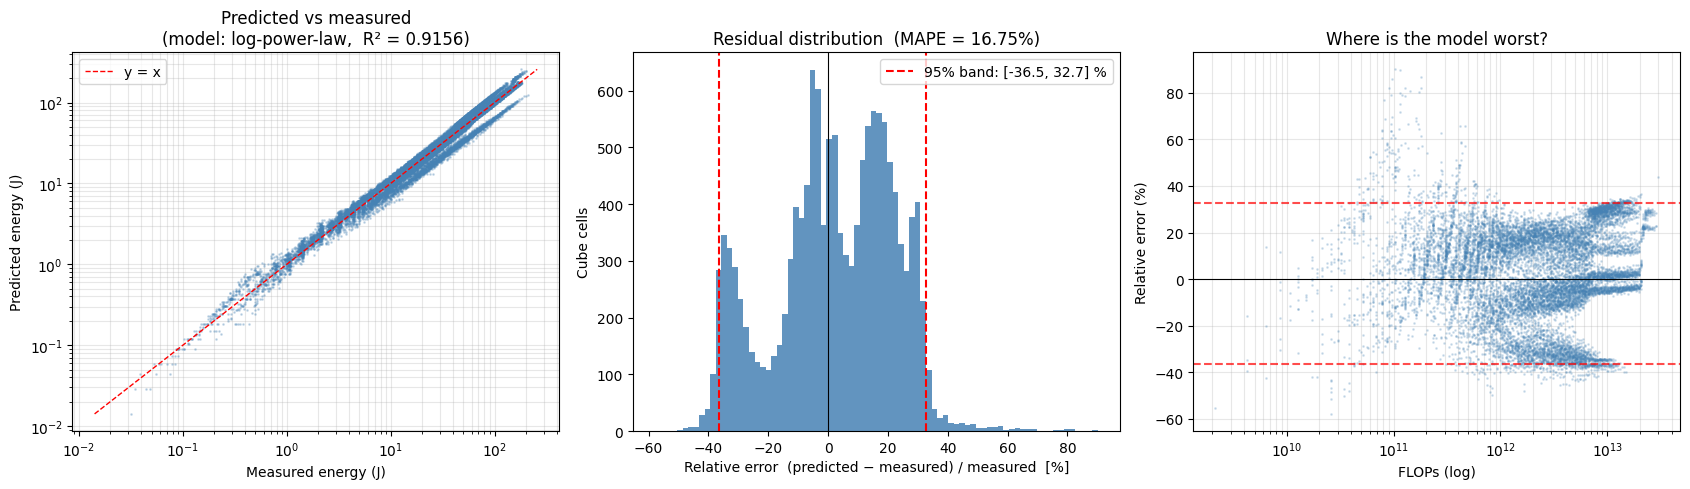

In [166]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Predicted vs measured (CV) on log-log axes
ax = axes[0]
ax.loglog(y, preds_cv, '.', ms=2, alpha=0.25, color='steelblue')
mn, mx = float(min(y.min(), preds_cv.min())), float(max(y.max(), preds_cv.max()))
ax.plot([mn, mx], [mn, mx], 'r--', lw=1, label='y = x')
ax.set_xlabel('Measured energy (J)')
ax.set_ylabel('Predicted energy (J)')
ax.set_title(f'Predicted vs measured\n(model: {best_name},  R² = {m["R2"]:.4f})')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

# (b) Relative error histogram
ax = axes[1]
rel_err_pct = (preds_cv - y) / np.maximum(np.abs(y), 1e-9) * 100
ax.hist(rel_err_pct, bins=80, color='steelblue', alpha=0.85)
lo_p, hi_p = np.percentile(rel_err_pct, [2.5, 97.5])
ax.axvline(0, color='k', lw=0.8)
ax.axvline(lo_p, color='red', ls='--', label=f'95% band: [{lo_p:.1f}, {hi_p:.1f}] %')
ax.axvline(hi_p, color='red', ls='--')
ax.set_xlabel('Relative error  (predicted − measured) / measured  [%]')
ax.set_ylabel('Cube cells')
ax.set_title(f'Residual distribution  (MAPE = {m["MAPE"]:.2f}%)')
ax.legend()

# (c) Relative error vs FLOPs — does error depend on problem size?
ax = axes[2]
flops_arr = 2.0 * M * N * K
ax.semilogx(flops_arr, rel_err_pct, '.', ms=2, alpha=0.2, color='steelblue')
ax.axhline(0, color='k', lw=0.8)
ax.axhline(lo_p, color='red', ls='--', alpha=0.7)
ax.axhline(hi_p, color='red', ls='--', alpha=0.7)
ax.set_xlabel('FLOPs (log)')
ax.set_ylabel('Relative error (%)')
ax.set_title('Where is the model worst?')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

## What's the second tier? — diagnosing the bimodality

The 3D cube clearly has two populations of points: an "efficient" tier and an "inefficient" tier, with the inefficient one carving out something close to a spherical region near the (16384, 16384, 16384) corner. A single linear/power-law fit can only average over both, so the residual band we computed earlier is dominated by which tier each point belongs to.

To pin it down we:

1. Compute **energy-per-FLOP**, `J/FLOP`. If only one regime were active, this would be a tight unimodal distribution. Two tiers ⇒ two modes.
2. Fit a 2-component **Gaussian mixture** in log(J/FLOP) and label each cell.
3. Find the geometric feature that best separates the labels (AUC of single-feature classifier) — distance from the high corner, `min(M, N, K)`, working-set size, etc. The best feature *is* the discriminator.
4. Refit the closed-form `E(M, N, K)` **per tier** so we can give a less-wrong answer once we know which regime a query lands in.

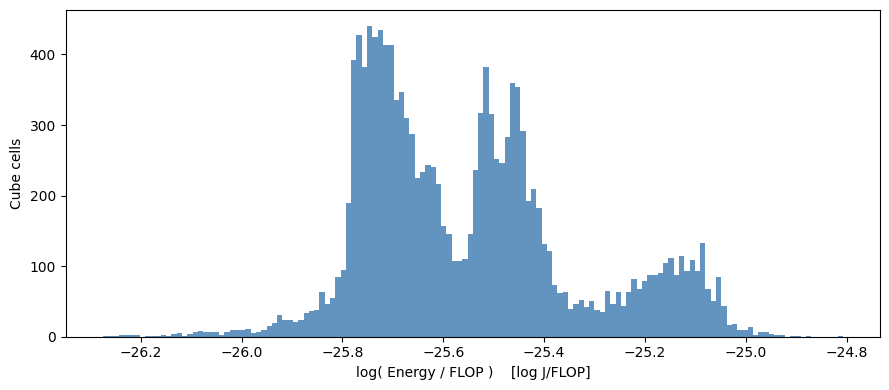

In [167]:
from sklearn.mixture import GaussianMixture

cube['EPF']     = cube['Energy_J'] / cube['FLOPs']        # J per FLOP
cube['log_EPF'] = np.log(cube['EPF'])

# Fit a 2-component GMM in log-J/FLOP space
gmm = GaussianMixture(n_components=2, random_state=0, n_init=4).fit(cube[['log_EPF']])
raw_labels = gmm.predict(cube[['log_EPF']])
order = np.argsort(gmm.means_.flatten())                  # 0 = efficient (low EPF)
relabel = {order[0]: 0, order[1]: 1}
cube['tier'] = pd.Series(raw_labels, index=cube.index).map(relabel)

mu0, mu1 = sorted(gmm.means_.flatten())
n0 = (cube['tier'] == 0).sum()
n1 = (cube['tier'] == 1).sum()
# print(f'Tier 0 (efficient):    {n0:>6,} cells   |  ⟨J/FLOP⟩ = {np.exp(mu0):.3e}   ({np.exp(mu0)*1e12:.2f} pJ/FLOP)')
# print(f'Tier 1 (inefficient):  {n1:>6,} cells   |  ⟨J/FLOP⟩ = {np.exp(mu1):.3e}   ({np.exp(mu1)*1e12:.2f} pJ/FLOP)')
# print(f'Inefficient tier costs ≈ {np.exp(mu1)/np.exp(mu0):.2f}× more energy per FLOP than efficient tier.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cube['log_EPF'], bins=140, color='steelblue', alpha=0.85)
# for mu, lbl in zip([mu0, mu1], ['tier 0 (efficient)', 'tier 1 (inefficient)']):
#     ax.axvline(mu, color='red', ls='--', lw=1.5)
#     ax.text(mu, ax.get_ylim()[1] * 0.95, f'  {lbl}\n  {np.exp(mu)*1e12:.2f} pJ/FLOP',
#             color='red', va='top', fontsize=9)
ax.set_xlabel('log( Energy / FLOP )    [log J/FLOP]')
ax.set_ylabel('Cube cells')
# ax.set_title('Energy per FLOP is bimodal — two physical regimes')
plt.tight_layout(); plt.show()

In [168]:
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Geometric / shape features the tier boundary could correspond to.
cube['dist_corner'] = np.sqrt((16384 - cube['m'])**2
                              + (16384 - cube['n'])**2
                              + (16384 - cube['k'])**2)
cube['min_dim']  = cube[['m', 'n', 'k']].min(axis=1)
cube['max_dim']  = cube[['m', 'n', 'k']].max(axis=1)
cube['mid_dim']  = cube[['m', 'n', 'k']].apply(lambda r: sorted(r.values)[1], axis=1)
cube['aspect']   = cube['max_dim'] / cube['min_dim']
cube['MNplusMKplusNK'] = cube['m']*cube['n'] + cube['m']*cube['k'] + cube['n']*cube['k']
cube['L2_radius'] = np.sqrt(cube['m']**2 + cube['n']**2 + cube['k']**2)

candidates = ['dist_corner', 'L2_radius', 'min_dim', 'mid_dim', 'max_dim', 'aspect',
              'FLOPs', 'Bytes', 'MNplusMKplusNK', 'AI', 'Duration', 'Power_W']

print(f"{'Feature':<18} {'AUC':>6}   {'best 1-D split (tier 0 ↔ tier 1)':>40}")
print('-' * 70)
ranked = []
for f in candidates:
    auc = roc_auc_score(cube['tier'], cube[f])
    auc_sym = max(auc, 1 - auc)                         # direction-agnostic
    tree = DecisionTreeClassifier(max_depth=1, random_state=0).fit(cube[[f]], cube['tier'])
    thr = tree.tree_.threshold[0]
    direction = '>' if cube.loc[cube[f] > thr, 'tier'].mean() > 0.5 else '<'
    ranked.append((f, auc_sym, thr, direction))

ranked.sort(key=lambda x: -x[1])
for f, auc, thr, direction in ranked:
    print(f'{f:<18} {auc:>6.3f}   {f} {direction} {thr:.4g}')

best_feat, best_auc, best_thr, best_dir = ranked[0]
print(f'\nMost separating feature: {best_feat}  (AUC = {best_auc:.3f})')
print(f'  Tier 1 (inefficient) ⇔  {best_feat} {best_dir} {best_thr:.4g}')

Feature               AUC           best 1-D split (tier 0 ↔ tier 1)
----------------------------------------------------------------------
max_dim             0.682   max_dim > 1.587e+04
Duration            0.644   Duration > 0.03178
L2_radius           0.637   L2_radius > 2.134e+04
Power_W             0.619   Power_W > 276.2
Bytes               0.598   Bytes > 1.648e+09
MNplusMKplusNK      0.598   MNplusMKplusNK > 2.06e+08
mid_dim             0.590   mid_dim < 6656
FLOPs               0.579   FLOPs > 8.461e+11
aspect              0.568   aspect > 2.045
AI                  0.545   AI > 547.3
dist_corner         0.510   dist_corner < 7765
min_dim             0.509   min_dim < 1.075e+04

Most separating feature: max_dim  (AUC = 0.682)
  Tier 1 (inefficient) ⇔  max_dim > 1.587e+04


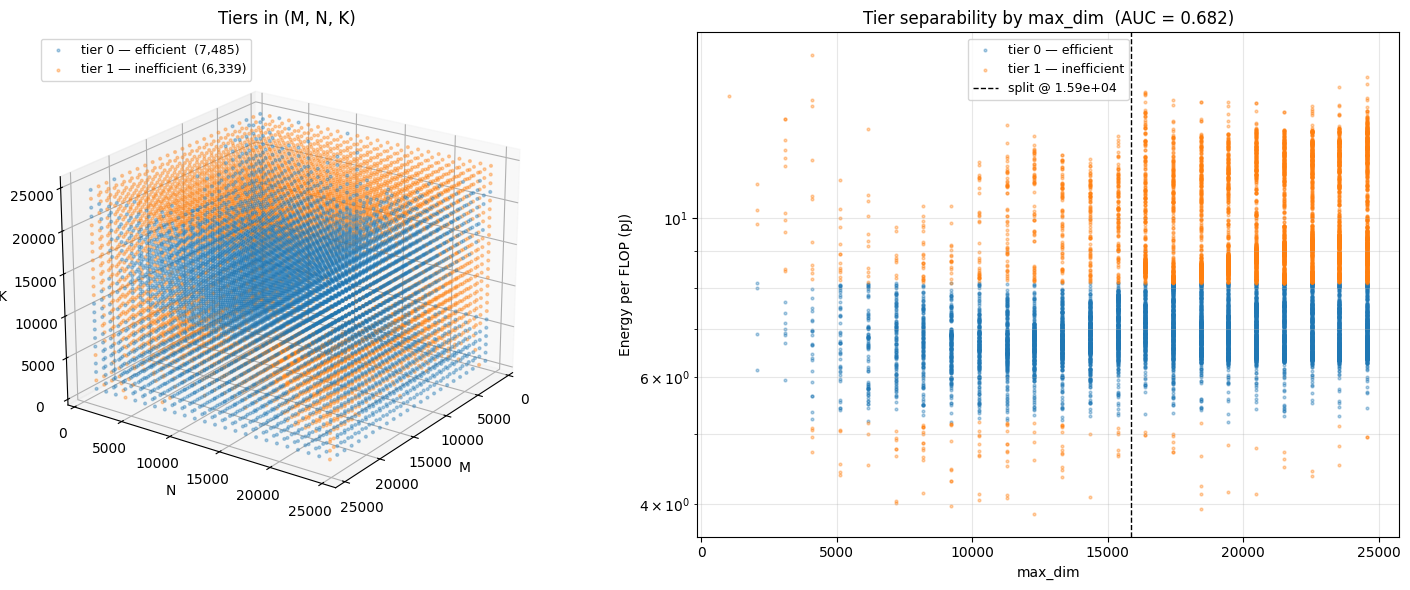

Per-tier diagnostics:
tier   cells    ⟨Power⟩ (W)    ⟨Duration⟩ (ms)    ⟨pJ/FLOP⟩       ⟨AI⟩
   0   7,485         265.97            104.614        6.896     783.18
   1   6,339         272.36            154.010        9.756     829.39


In [169]:
fig = plt.figure(figsize=(15, 6))

# (a) tiers in (M, N, K)
ax = fig.add_subplot(1, 2, 1, projection='3d')
for t, color, lbl in [(0, 'tab:blue', f'tier 0 — efficient  ({n0:,})'),
                       (1, 'tab:orange', f'tier 1 — inefficient ({n1:,})')]:
    sub = cube[cube['tier'] == t]
    ax.scatter(sub['m'], sub['n'], sub['k'], c=color, s=4, alpha=0.35, label=lbl)
ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
ax.set_title('Tiers in (M, N, K)')
ax.view_init(elev=22, azim=35); ax.legend(loc='upper left', fontsize=9)

# (b) tier vs the most-separating feature
ax = fig.add_subplot(1, 2, 2)
for t, color, lbl in [(0, 'tab:blue', 'tier 0 — efficient'),
                       (1, 'tab:orange', 'tier 1 — inefficient')]:
    sub = cube[cube['tier'] == t]
    ax.scatter(sub[best_feat], sub['EPF'] * 1e12, c=color, s=4, alpha=0.35, label=lbl)
ax.axvline(best_thr, color='k', ls='--', lw=1, label=f'split @ {best_thr:.3g}')
ax.set_xlabel(best_feat)
ax.set_ylabel('Energy per FLOP (pJ)')
ax.set_yscale('log')
ax.set_title(f'Tier separability by {best_feat}  (AUC = {best_auc:.3f})')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

# Per-tier behaviour summary
print('Per-tier diagnostics:')
print(f"{'tier':>4} {'cells':>7} {'⟨Power⟩ (W)':>14} {'⟨Duration⟩ (ms)':>18} {'⟨pJ/FLOP⟩':>12} {'⟨AI⟩':>10}")
for t in [0, 1]:
    s = cube[cube['tier'] == t]
    print(f"{t:>4} {len(s):>7,} {s['Power_W'].mean():>14.2f} "
          f"{s['Duration'].mean()*1000:>18.3f} {s['EPF'].mean()*1e12:>12.3f} {s['AI'].mean():>10.2f}")

In [170]:
# Refit the closed-form roofline equation per tier, with CV error.
def fit_with_cv(sub, kind='roofline'):
    Xs = make_features(sub['m'].values, sub['n'].values, sub['k'].values, kind)
    ys = sub['Energy_J'].values
    kf = KFold(5, shuffle=True, random_state=0)
    preds = np.zeros_like(ys, dtype=float)
    for tr, te in kf.split(Xs):
        preds[te] = LinearRegression().fit(Xs[tr], ys[tr]).predict(Xs[te])
    full = LinearRegression().fit(Xs, ys)
    mape = np.mean(np.abs((ys - preds) / np.maximum(np.abs(ys), 1e-9))) * 100
    rmse = np.sqrt(np.mean((ys - preds) ** 2))
    return full, mape, rmse


per_tier_models = {}
print('Per-tier closed-form fits  (kind = roofline):\n')
for t in [0, 1]:
    sub = cube[cube['tier'] == t]
    mdl, mape, rmse = fit_with_cv(sub, 'roofline')
    per_tier_models[t] = mdl
    print(f'Tier {t}  (n = {len(sub):,})')
    print(f'  E = {mdl.intercept_:+.4e}'
          f'  +  {mdl.coef_[0]:+.4e} · (2·M·N·K)'
          f'  +  {mdl.coef_[1]:+.4e} · 8·(M·K + K·N + M·N)   [J]')
    print(f'  CV MAPE = {mape:.2f} %     CV RMSE = {rmse:.4f} J')
    print(f'  → per-FLOP cost ≈ {mdl.coef_[0]*1e12:.3f} pJ/FLOP')
    print(f'  → per-byte cost ≈ {mdl.coef_[1]*1e12:.3f} pJ/byte\n')


def predict_energy_two_tier(M, N, K):
    """E(M, N, K) using the tier-1 / tier-0 boundary identified above."""
    M, N, K = np.atleast_1d(M), np.atleast_1d(N), np.atleast_1d(K)
    feat_val = (np.sqrt((16384 - M)**2 + (16384 - N)**2 + (16384 - K)**2)
                if best_feat == 'dist_corner'
                else (np.sqrt(M**2 + N**2 + K**2) if best_feat == 'L2_radius'
                      else (np.minimum(np.minimum(M, N), K) if best_feat == 'min_dim'
                            else (np.maximum(np.maximum(M, N), K) if best_feat == 'max_dim'
                                  else 2.0 * M * N * K))))                # FLOPs fallback
    is_tier1 = (feat_val > best_thr) if best_dir == '>' else (feat_val < best_thr)
    Xq = make_features(M, N, K, 'roofline')
    out = np.where(is_tier1,
                   per_tier_models[1].predict(Xq),
                   per_tier_models[0].predict(Xq))
    return out


print('Sanity-check predictions (two-tier model):')
print(f"  {'M':>6} {'N':>6} {'K':>6}   {'E_pred (J)':>12}   {'measured (J)':>12}   {'tier':>4}")
for Mi, Ni, Ki in [(512, 512, 512), (4096, 4096, 4096),
                   (8192, 8192, 8192), (16384, 16384, 16384),
                   (1024, 16384, 16384), (16384, 1024, 1024)]:
    yhat = predict_energy_two_tier(Mi, Ni, Ki)[0]
    actual = cube.set_index(['m', 'n', 'k'])['Energy_J'].get((Mi, Ni, Ki), np.nan)
    actual_s = f'{actual:12.4f}' if np.isfinite(actual) else f'{"—":>12}'
    feat_val_one = {
        'dist_corner': np.sqrt((16384-Mi)**2 + (16384-Ni)**2 + (16384-Ki)**2),
        'L2_radius':   np.sqrt(Mi**2 + Ni**2 + Ki**2),
        'min_dim':     min(Mi, Ni, Ki),
        'max_dim':     max(Mi, Ni, Ki),
    }.get(best_feat, 2.0*Mi*Ni*Ki)
    is_t1 = (feat_val_one > best_thr) if best_dir == '>' else (feat_val_one < best_thr)
    print(f'  {Mi:6d} {Ni:6d} {Ki:6d}   {yhat:12.4f}   {actual_s}   {int(is_t1):>4}')

Per-tier closed-form fits  (kind = roofline):

Tier 0  (n = 7,485)
  E = -1.4215e-01  +  +6.7932e-12 · (2·M·N·K)  +  +1.6874e-10 · 8·(M·K + K·N + M·N)   [J]
  CV MAPE = 7.35 %     CV RMSE = 3.0029 J
  → per-FLOP cost ≈ 6.793 pJ/FLOP
  → per-byte cost ≈ 168.741 pJ/byte

Tier 1  (n = 6,339)
  E = -2.0339e+00  +  +7.4249e-12 · (2·M·N·K)  +  +2.7180e-09 · 8·(M·K + K·N + M·N)   [J]
  CV MAPE = 31.10 %     CV RMSE = 8.9988 J
  → per-FLOP cost ≈ 7.425 pJ/FLOP
  → per-byte cost ≈ 2718.031 pJ/byte

Sanity-check predictions (two-tier model):
       M      N      K     E_pred (J)   measured (J)   tier
     512    512    512        -0.1393              —      0
    4096   4096   4096         0.8595         1.0315      0
    8192   8192   8192         7.5989         7.6780      0
   16384  16384  16384        80.7867        73.0728      1
    1024  16384  16384         8.6146         4.8556      1
   16384   1024   1024        -1.0263         0.3646      1


## Simple closed-form prediction — and where it deviates

Fit one straightforward equation to (M, N, K) → Energy and then plot the residual as a 3D heatmap cube. Regions where the simple equation is wrong show up as coloured "blobs" in (M, N, K) space and immediately reveal the structure that no single formula can capture.

We use a 4-parameter power law (it spans the three decades of energy gracefully and keeps the form short enough to read):

$$E(M, N, K) \;\approx\; A \cdot M^{a} \cdot N^{b} \cdot K^{c}$$

In [171]:
# Fit  log E = log A + a·log M + b·log N + c·log K  (one global power law).
X_simple = np.column_stack([np.log(cube['m']), np.log(cube['n']), np.log(cube['k'])])
y_log = np.log(cube['Energy_J'].values)
simple = LinearRegression().fit(X_simple, y_log)
a_e, b_e, c_e = simple.coef_
A_e = float(np.exp(simple.intercept_))

cube['E_simple_pred'] = A_e * cube['m']**a_e * cube['n']**b_e * cube['k']**c_e
cube['err_J']         = cube['E_simple_pred'] - cube['Energy_J']
cube['err_pct']       = 100.0 * cube['err_J'] / cube['Energy_J']

mape  = np.mean(np.abs(cube['err_pct']))
medae = np.median(np.abs(cube['err_pct']))
lo, hi = np.percentile(cube['err_pct'], [2.5, 97.5])

print(f'Closed-form equation:')
print(f'   E(M, N, K)  =  {A_e:.4e} · M^{a_e:.4f} · N^{b_e:.4f} · K^{c_e:.4f}     [J]')
print()
print(f'Sum of exponents a + b + c = {a_e + b_e + c_e:.4f}'
      f'   (= 3 would mean E ∝ FLOPs perfectly)')
print()
print(f'Prediction error on the same cube (in-sample):')
print(f'   MAPE                       {mape:.2f} %')
print(f'   median |relative error|    {medae:.2f} %')
print(f'   95% band of relative err   [{lo:+.2f}, {hi:+.2f}] %')

Closed-form equation:
   E(M, N, K)  =  7.2618e-12 · M^1.0259 · N^1.0284 · K^1.0315     [J]

Sum of exponents a + b + c = 3.0859   (= 3 would mean E ∝ FLOPs perfectly)

Prediction error on the same cube (in-sample):
   MAPE                       16.75 %
   median |relative error|    15.08 %
   95% band of relative err   [-36.51, +32.63] %


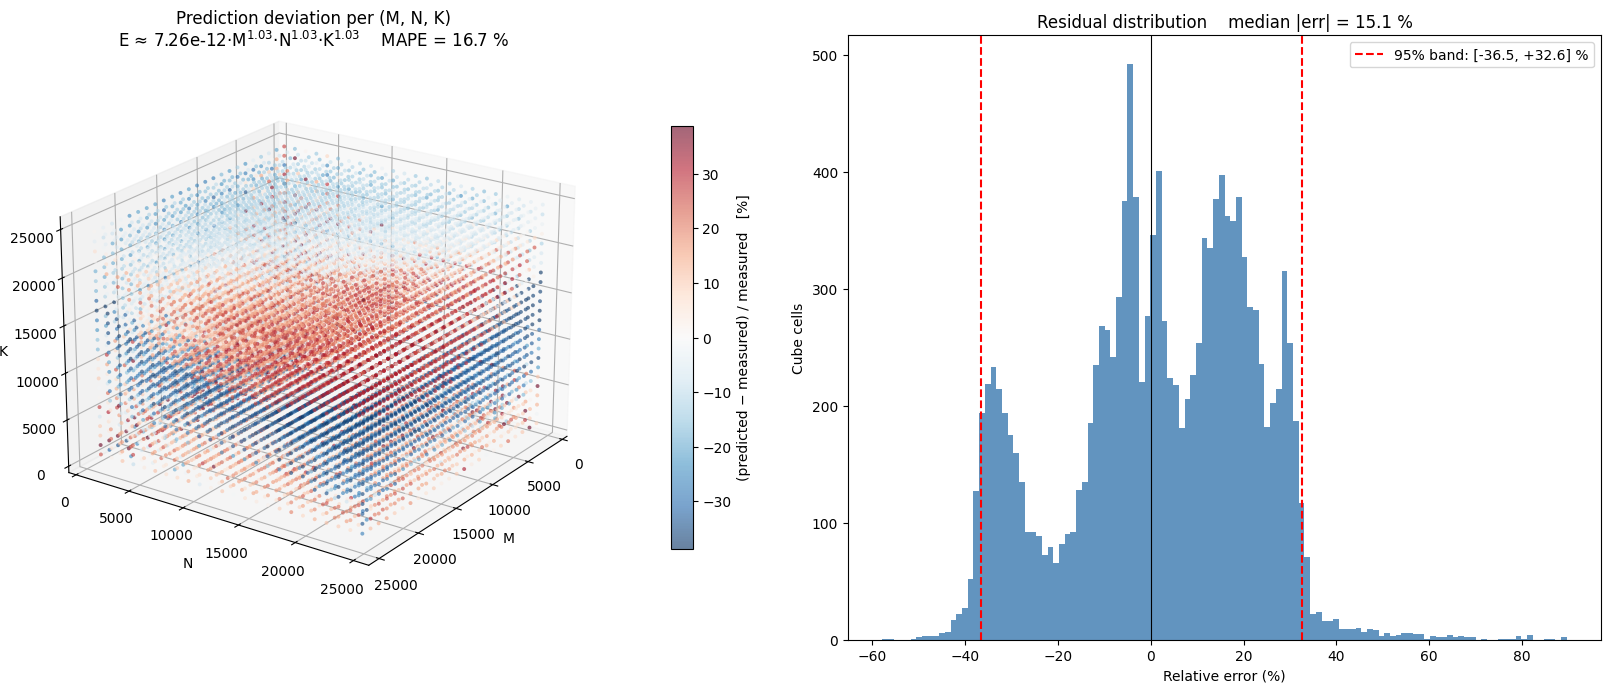

In [172]:
# 3D heatmap cube of the prediction error, plus residual histogram side-by-side.
vmax = float(np.percentile(np.abs(cube['err_pct']), 98))

fig = plt.figure(figsize=(16, 7))

ax = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax.scatter(
    cube['m'], cube['n'], cube['k'],
    c=cube['err_pct'], cmap='RdBu_r',
    s=8, alpha=0.6, vmin=-vmax, vmax=vmax, edgecolors='none',
)
ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
ax.set_title(
    f'Prediction deviation per (M, N, K)\n'
    f'E ≈ {A_e:.2e}·M$^{{{a_e:.2f}}}$·N$^{{{b_e:.2f}}}$·K$^{{{c_e:.2f}}}$    '
    f'MAPE = {mape:.1f} %'
)
ax.view_init(elev=22, azim=35)
cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cb.set_label('(predicted − measured) / measured   [%]')

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(cube['err_pct'], bins=120, color='steelblue', alpha=0.85)
ax2.axvline(0, color='k', lw=0.8)
ax2.axvline(lo, color='red', ls='--', label=f'95% band: [{lo:+.1f}, {hi:+.1f}] %')
ax2.axvline(hi, color='red', ls='--')
ax2.set_xlabel('Relative error (%)')
ax2.set_ylabel('Cube cells')
ax2.set_title(f'Residual distribution    median |err| = {medae:.1f} %')
ax2.legend()
plt.tight_layout(); plt.show()

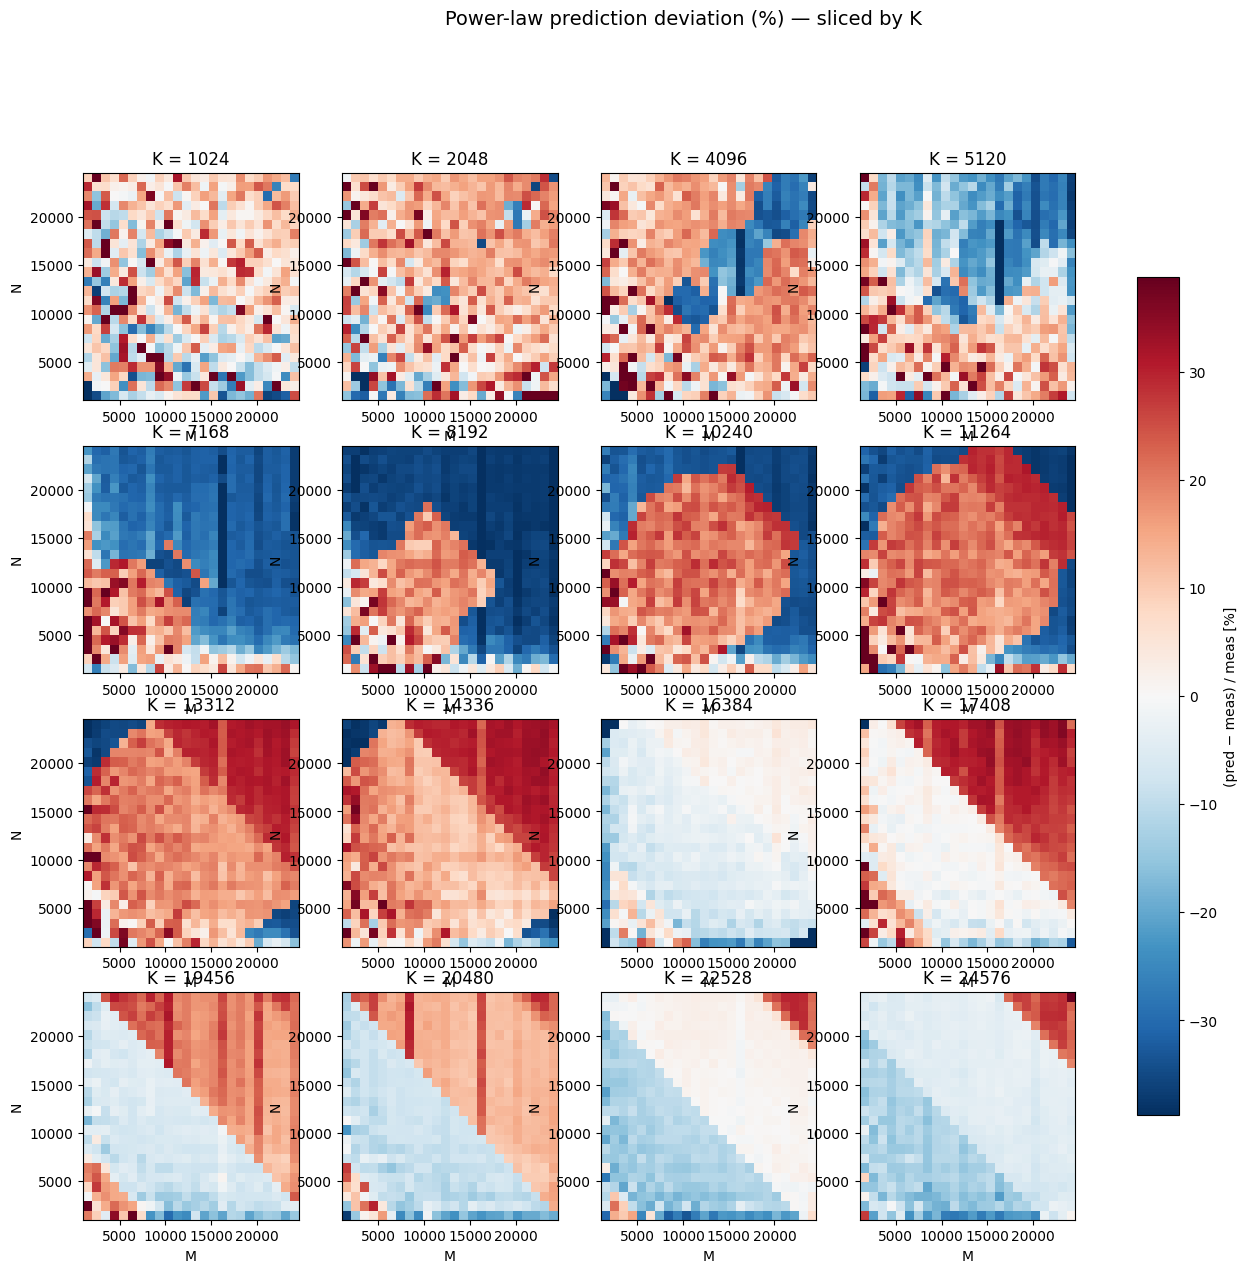

In [173]:
# 2D K-slice panels of the deviation — easier to read than a 3D scatter.
k_values = sorted(cube['k'].unique())
if len(k_values) > 16:
    idx = np.linspace(0, len(k_values) - 1, 16).astype(int)
    k_values = [k_values[i] for i in idx]

cols = 4
rows = int(np.ceil(len(k_values) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows), squeeze=False)
for ax, k in zip(axes.flat, k_values):
    pivot = (cube[cube['k'] == k]
             .pivot_table(index='n', columns='m', values='err_pct', aggfunc='mean')
             .sort_index().sort_index(axis=1))
    im = ax.imshow(pivot.values, origin='lower', aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax,
                   extent=[pivot.columns.min(), pivot.columns.max(),
                           pivot.index.min(), pivot.index.max()])
    ax.set_title(f'K = {k}')
    ax.set_xlabel('M'); ax.set_ylabel('N')
for ax in axes.flat[len(k_values):]:
    ax.axis('off')
fig.suptitle('Power-law prediction deviation (%) — sliced by K', y=1.0, fontsize=14)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='(pred − meas) / meas [%]')
plt.show()

In [174]:
# Interactive Plotly version of the deviation cube — drag to rotate, hover for details.
import plotly.graph_objects as go

vmax_p = float(np.percentile(np.abs(cube['err_pct']), 98))

fig = go.Figure(go.Scatter3d(
    x=cube['m'], y=cube['n'], z=cube['k'],
    mode='markers',
    marker=dict(
        size=3.5,
        color=cube['err_pct'],
        colorscale='RdBu_r',
        cmin=-vmax_p, cmax=vmax_p, cmid=0,
        opacity=0.85,
        colorbar=dict(title='(pred − meas) / meas  [%]'),
    ),
    customdata=np.stack([
        cube['Energy_J'].values,
        cube['E_simple_pred'].values,
        cube['err_pct'].values,
    ], axis=-1),
    hovertemplate=(
        'M=%{x}, N=%{y}, K=%{z}<br>'
        'measured  = %{customdata[0]:.3f} J<br>'
        'predicted = %{customdata[1]:.3f} J<br>'
        'error     = %{customdata[2]:+.2f} %<extra></extra>'
    ),
))

fig.update_layout(
    title=(f'Prediction deviation in (M, N, K) — interactive<br>'
           f'<sub>E ≈ {A_e:.2e} · M^{a_e:.2f} · N^{b_e:.2f} · K^{c_e:.2f}    '
           f'MAPE = {mape:.1f}%</sub>'),
    scene=dict(xaxis_title='M', yaxis_title='N', zaxis_title='K'),
    height=700, width=900,
)
fig.show()

## Better fits — a model bake-off

The single global power law `E = A·M^a·N^b·K^c` has to average over the two-regime structure we found earlier, so its relative error is bound to be terrible in one tier or the other. We compare several alternatives, all scored by 5-fold cross-validated MAPE so the numbers are honest generalization error, not training error:

1. **Power law** (current baseline).
2. **Power law + skinny-matrix penalty** — adds `log(min(M, N, K))` since `min` is the dimension that controls kernel tiling efficiency.
3. **Roofline** — `E = c0 + c1·FLOPs + c2·Bytes` on the linear scale (the physically motivated form).
4. **7-term polynomial** — linear in `{M, N, K, M·N, M·K, N·K, M·N·K}`.
5. **Per-tier power law** — fits the power law separately on tier 0 and tier 1 (the GMM labels from earlier).
6. **Gradient-boosted trees** — non-parametric upper bound on what's achievable from `(M, N, K)` alone.

Whichever wins gets re-rendered as a 3D deviation cube to show where it still struggles.

In [175]:
from sklearn.ensemble import GradientBoostingRegressor

# Make sure the GMM tier labels exist (the diagnostic section computes them).
if 'tier' not in cube.columns:
    from sklearn.mixture import GaussianMixture
    epf = (cube['Energy_J'] / cube['FLOPs']).values.reshape(-1, 1)
    g = GaussianMixture(n_components=2, random_state=0, n_init=4).fit(np.log(epf))
    raw = g.predict(np.log(epf))
    order = np.argsort(g.means_.flatten())
    cube['tier'] = pd.Series(raw).map({order[0]: 0, order[1]: 1}).values

y      = cube['Energy_J'].values
y_log  = np.log(y)
Mv, Nv, Kv = cube['m'].values, cube['n'].values, cube['k'].values
flops  = 2.0 * Mv * Nv * Kv
bytes_ = 8.0 * (Mv*Kv + Kv*Nv + Mv*Nv)
min_d  = np.minimum(np.minimum(Mv, Nv), Kv)
max_d  = np.maximum(np.maximum(Mv, Nv), Kv)
tier   = cube['tier'].values


def cv_predict(X, fit_predict, n_splits=5):
    """Return out-of-fold predictions on the original Joule scale."""
    kf = KFold(n_splits, shuffle=True, random_state=0)
    preds = np.zeros(len(X), dtype=float)
    for tr, te in kf.split(X):
        preds[te] = fit_predict(X, tr, te)
    return preds


def lin_J(X, tr, te):           # plain linear regression on Joules
    return LinearRegression().fit(X[tr], y[tr]).predict(X[te])

def lin_logJ(X, tr, te):        # linear regression on log(Joules), back-transform
    return np.exp(LinearRegression().fit(X[tr], y_log[tr]).predict(X[te]))

def per_tier_logJ(X, tr, te):   # separate log-J regression per tier
    out = np.zeros(len(te))
    for t in (0, 1):
        tr_t = tr[tier[tr] == t]
        te_t = te[tier[te] == t]
        if tr_t.size == 0 or te_t.size == 0:
            continue
        mdl = LinearRegression().fit(X[tr_t], y_log[tr_t])
        out[np.isin(te, te_t)] = np.exp(mdl.predict(X[te_t]))
    return out

def gbr_J(X, tr, te):           # gradient boosted trees on Joules
    mdl = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                    learning_rate=0.08, random_state=0)
    mdl.fit(X[tr], y[tr])
    return mdl.predict(X[te])


candidates = [
    ('power law  A·M^a·N^b·K^c',
         np.column_stack([np.log(Mv), np.log(Nv), np.log(Kv)]),                lin_logJ),
    ('power law + log(min(M,N,K)) penalty',
         np.column_stack([np.log(Mv), np.log(Nv), np.log(Kv), np.log(min_d)]), lin_logJ),
    ('roofline   c0 + c1·FLOPs + c2·Bytes',
         np.column_stack([flops, bytes_]),                                     lin_J),
    ('7-term polynomial in M,N,K, products',
         np.column_stack([Mv, Nv, Kv, Mv*Nv, Mv*Kv, Nv*Kv, flops]),            lin_J),
    ('per-tier power law (2 fits)',
         np.column_stack([np.log(Mv), np.log(Nv), np.log(Kv)]),                per_tier_logJ),
    ('gradient-boosted trees (no closed form)',
         np.column_stack([Mv, Nv, Kv, flops, bytes_, min_d, max_d, max_d/min_d]), gbr_J),
]

scores = []
print(f"{'Model':<42} {'CV MAPE %':>12} {'CV RMSE (J)':>14} {'R²':>8}")
print('-' * 80)
for name, X, fp in candidates:
    p = cv_predict(X, fp)
    mape = float(np.mean(np.abs((p - y) / np.maximum(np.abs(y), 1e-9))) * 100)
    rmse = float(np.sqrt(np.mean((p - y)**2)))
    r2   = float(1 - ((y - p)**2).sum() / ((y - y.mean())**2).sum())
    scores.append((name, p, mape, rmse, r2))
    print(f'{name:<42} {mape:>12.2f} {rmse:>14.4f} {r2:>8.4f}')

best_idx = int(np.argmin([s[2] for s in scores]))
best_name, best_preds, best_mape, best_rmse, best_r2 = scores[best_idx]
print(f'\nWinner: {best_name}')
print(f'  CV MAPE = {best_mape:.2f} %   CV RMSE = {best_rmse:.4f} J   R² = {best_r2:.4f}')

Model                                         CV MAPE %    CV RMSE (J)       R²
--------------------------------------------------------------------------------
power law  A·M^a·N^b·K^c                          16.75        10.7554   0.9156
power law + log(min(M,N,K)) penalty               16.09        10.2651   0.9231
roofline   c0 + c1·FLOPs + c2·Bytes               58.09         9.5265   0.9338
7-term polynomial in M,N,K, products              47.62         9.3435   0.9363
per-tier power law (2 fits)                        9.26         6.3668   0.9704
gradient-boosted trees (no closed form)            9.80         2.5995   0.9951

Winner: per-tier power law (2 fits)
  CV MAPE = 9.26 %   CV RMSE = 6.3668 J   R² = 0.9704


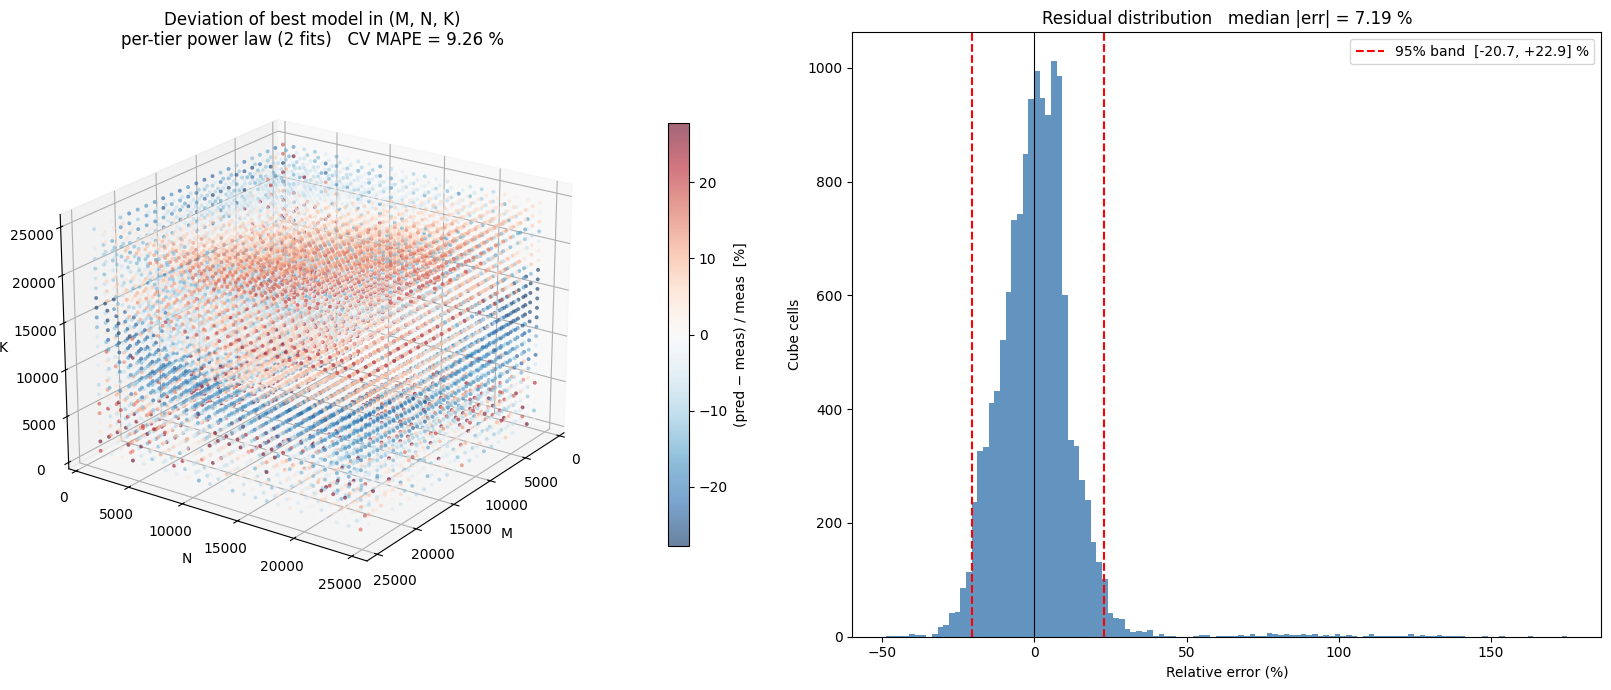

In [177]:
# Render the deviation cube for the best model (held-out CV predictions).
cube['E_best_pred']   = best_preds
cube['err_best_J']    = cube['E_best_pred'] - cube['Energy_J']
cube['err_best_pct']  = 100.0 * cube['err_best_J'] / cube['Energy_J']

lo_b, hi_b = np.percentile(cube['err_best_pct'], [2.5, 97.5])
med_b      = float(np.median(np.abs(cube['err_best_pct'])))
vmax_b     = float(np.percentile(np.abs(cube['err_best_pct']), 98))

fig = plt.figure(figsize=(16, 7))

ax = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax.scatter(cube['m'], cube['n'], cube['k'],
                c=cube['err_best_pct'], cmap='RdBu_r',
                s=8, alpha=0.6, vmin=-vmax_b, vmax=vmax_b, edgecolors='none')
ax.set_xlabel('M'); ax.set_ylabel('N'); ax.set_zlabel('K')
ax.set_title(f'Deviation of best model in (M, N, K)\n'
             f'{best_name}   CV MAPE = {best_mape:.2f} %')
ax.view_init(elev=22, azim=35)
fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1,
             label='(pred − meas) / meas  [%]')

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(cube['err_best_pct'], bins=120, color='steelblue', alpha=0.85)
ax2.axvline(0, color='k', lw=0.8)
ax2.axvline(lo_b, color='red', ls='--',
            label=f'95% band  [{lo_b:+.1f}, {hi_b:+.1f}] %')
ax2.axvline(hi_b, color='red', ls='--')
ax2.set_xlabel('Relative error (%)'); ax2.set_ylabel('Cube cells')
ax2.set_title(f'Residual distribution   median |err| = {med_b:.2f} %')
ax2.legend()
plt.tight_layout(); plt.show()

In [178]:
# Interactive Plotly deviation cube for the best model.
fig = go.Figure(go.Scatter3d(
    x=cube['m'], y=cube['n'], z=cube['k'], mode='markers',
    marker=dict(
        size=3.5, color=cube['err_best_pct'],
        colorscale='RdBu_r', cmin=-vmax_b, cmax=vmax_b, cmid=0,
        opacity=0.85,
        colorbar=dict(title='(pred − meas) / meas  [%]'),
    ),
    customdata=np.stack([
        cube['Energy_J'].values,
        cube['E_best_pred'].values,
        cube['err_best_pct'].values,
    ], axis=-1),
    hovertemplate=(
        'M=%{x}, N=%{y}, K=%{z}<br>'
        'measured  = %{customdata[0]:.3f} J<br>'
        'predicted = %{customdata[1]:.3f} J<br>'
        'error     = %{customdata[2]:+.2f} %<extra></extra>'
    ),
))
fig.update_layout(
    title=(f'Deviation cube — best model<br>'
           f'<sub>{best_name}    CV MAPE = {best_mape:.2f}%   median |err| = {med_b:.2f}%</sub>'),
    scene=dict(xaxis_title='M', yaxis_title='N', zaxis_title='K'),
    height=700, width=900,
)
fig.show()